# 30_05 — PSBPM-FD contra FAR y RF · Metro Interstate (I-94) horario · volumen de tráfico · **barrido en $M$**

Paso **3c**, posterior a `30_04_evaluacion`. Reúne **todas** las métricas y comparaciones
del PSBPM-FD contra sus dos referencias, sobre el mismo conjunto de información y con
**las mismas métricas que el `30_04`**: si los dos notebooks midieran cosas distintas, la
comparación entre modelos no sería la misma que la del barrido en $M$.

Los cálculos viven en `fit/comparacion_barrido.py` y las figuras en
`graphics/viz_comparacion.py`; este notebook los orquesta. La predicción y la banda del
PSBPM-FD se **leen** de `banda_funcional_psbp.npz` (lo persiste `30_04`): no se recalcula
nada desde las trazas.

| Sección | Qué responde |
|---|---|
| 1 | `[CONFIG]`, artefactos y diseño común |
| 2 | validaciones: mismo corte, mismas covariables, mismo objetivo para todos |
| 3 | los competidores: FAR(p), Random Forest (mismas covariables cruzadas) y el PSBPM-FD |
| 4 | **Bloque A** (MAE, RMSE, error máximo) — los tres modelos |
| 5 | **Bloque B** (Winkler, cobertura simultánea, PICP, MPIW) — sólo FAR y PSBPM-FD |
| 6 | Bloque A: % de ventanas ganadas y cuánto mejor es cada modelo |
| 7 | Bloque B: lo mismo, sobre las bandas |
| 8 | resumen: mínimo, máximo y promedio por ventana, y las métricas contra $M$ |
| 9 | los orígenes mejor y peor predichos, con las dos bandas superpuestas |

> **Corrida 30 — Metro Interstate (I-94), volumen de tráfico horario.** Pipeline de la 200 sobre datos reales: covariables cruzadas con un solo rezago (`N_LAGS = 1`, $p=M$), `M = 1..6` entrenando cada `M`, sampler corregido (`[FIX 3]`–`[FIX 6]`), variante `chungEscG` (Chung y Dunson §4.2 en escala cruda, gating más libre). Representación B-spline por GCV y FPCA estimadas en train. El objetivo de evaluación es la curva suavizada; no hay curva verdadera.


## 1. Imports, `[CONFIG]` y artefactos

In [1]:
import sys

import matplotlib.pyplot as plt

from model_psbp_fd.fit.convergencia_barrido import cargar_artefactos
from model_psbp_fd.fit.evaluacion_barrido import (
    METRICAS_A as _MA, METRICAS_B as _MB, cargar_representaciones, serie_origenes,
)
from model_psbp_fd.fit.comparacion_barrido import (
    G_FAR, G_PSG, G_PSB, PISO,
    preparar_diseno, ajustar_far, ajustar_rf, cargar_psbp,
    tablas_modelos, verificar_cadena_modelos,
    construir_bandas, tabla_bloque_B, ventana_bloque_B,
    ganadores_por_ventana, resumen_min_max, promedio_vs_M,
    origenes_extremos, contraste_origenes,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, ESTILOS_MODELOS,
    plot_ganador_modelo, plot_metricas_vs_M, plot_bandas_contraste,
)
from model_psbp_fd.utils import get_project_root, experiment_id, normalizar_lista_M
from model_psbp_fd.utils.rutas import ruta_barrido_M

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Identidad de la corrida: mismos valores que 30_01 §1.1. El ID es
# real_<serie>_v<NN>_m<NN>; las funciones de fit/ lo arman con (BASE_LIB, ESCENARIO_ID, None).
BASENAME, SERIE_ID, VENTANA_ID = "real", "trafico_mi", 1   # ventana 1: 2015-07-01 .. 2018-09-30, 70/30 (30_01 §1.1)
M_FPCA_LIST = (1, 2, 3, 4, 5, 6)
DOMINIO      = "reales"
BASE_LIB     = f"{BASENAME}_{SERIE_ID}"
ESCENARIO_ID = f"v{VENTANA_ID:02d}"
REPLICA_ID   = None

# Propias de la comparación. Ventanas, nivel y objetivo se LEEN de eval_config.json
# (artefacto de 30_01): no se redeclaran aquí.
PESOS_TAU = None          # cuadratura trapezoidal por defecto
PREFIJO   = 70            # este notebook escribe 70-79 en cada M y 96-99 en el barrido

# FAR (§3.1): tope del barrido de kn (acota en K, no en L) y criterio de far.cv.
KN_MAX      = 12
CRITERIO_KN = "L2"

# Random Forest (§3.2): hiperparámetros fijos entre escenarios y entre puntos del barrido.
SEED_ML   = 20260830
PARAMS_RF = dict(n_estimators=500, min_samples_leaf=5, max_features="sqrt",
                 random_state=SEED_ML, n_jobs=-1)

# Bloque B (§5): FAR con banda gaussiana de residuos de train y PSBPM-FD con su banda
# nativa (cuantiles de su predictiva).
IC_POR_TAU                = True    # sigma_eps(tau) punto a punto (False = ancho constante)
IC_CORRECCION_ESTIMACION  = True    # infla sigma por sqrt(1 + kn/n_train)
IC_PSBP_TAMBIEN_GAUSSIANA = False   # control opcional: no se corre (sólo FAR gaussiano y PSBPM-FD nativo)

# §9: por qué métrica se eligen los orígenes extremos, cuántos, qué dos bandas se
# contrastan (prefijos, en orden) y en qué M (None = todos).
METRICA_SEL_IC     = "rmse_f"     # una de METRICAS_A_COLS
N_EXTREMOS         = 5
BANDA_A_CONTRASTAR = ("FAR", "PSBPM-FD (predictiva")
M_DETALLE          = None

# Las 10 métricas del marco teórico 02_02_03, en su orden. No se agregan otras.
METRICAS_A = [("1. MAE  (L^1)", "mae_f"), ("2. RMSE (L^2)", "rmse_f"),
              ("3. E_max promedio por curva", "linf_medio"),
              ("4. E_max peor de la ventana", "linf_max")]
METRICAS_B = [("5. MPIW", "mpiw"), ("6. PICP puntual", "picp"),
              ("7. PICPB curva completa", "picp_simultaneo"), ("8. Winkler", "winkler"),
              ("9. Winkler max promedio", "winkler_max_medio"),
              ("10. Winkler max peor ventana", "winkler_max_glob")]
assert METRICAS_A == _MA and METRICAS_B == _MB, "METRICAS_* difieren de fit.evaluacion_barrido."
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]
assert METRICA_SEL_IC in METRICAS_A_COLS[:3], "METRICA_SEL_IC: mae_f, rmse_f o linf_medio."

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASE_LIB, ESCENARIO_ID, REPLICA_ID)
PATH_BARRIDO    = ruta_barrido_M(BASE_LIB, ESCENARIO_ID, REPLICA_ID, dominio=DOMINIO,
                                 project_root=PROJECT_ROOT)

print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
print(f"salidas cruzadas: {PATH_BARRIDO}   (archivos 96-99)")

EXPERIMENT_BASE : real_trafico_mi_v01
barrido en M    : [1, 2, 3, 4, 5, 6]
salidas cruzadas: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_mi_v01_barrido_M   (archivos 96-99)


In [3]:
# EST[M]: estado de cada punto (cruza el contrato al cargar). DIS: diseño común.
EST, saltados = cargar_artefactos(BASE_LIB, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                                  PROJECT_ROOT, con_test=True, dominio=DOMINIO)
DIS  = cargar_representaciones(EST)
ORIG = serie_origenes(DIS)

T0, N_LAGS, NIVEL = DIS["T0"], DIS["N_LAGS"], DIS["NIVEL"]
VENTANAS_W, W_REF = DIS["VENTANAS_W"], DIS["W_REF"]
grilla, X_obj_ev  = DIS["grilla"], ORIG["X_obj_ev"]
t_orig, es_train  = ORIG["t_orig"], ORIG["es_train"]

  M  comp  cadenas  covariables  seed_base
  1     1        1            1  41232
  2     2        1            2  41232
  3     3        1            3  41232
  4     4        1            4  41232
  5     5        1            5  41232
  6     6        1            6  41232

OK misma configuracion MCMC en todos los M: nsim/N/burn/cadenas = (2500, 30, 500, 1)
M=1  FPCA M=1 K=10  var. explicada=79.8764%  ·  curvas (1188, 24)
M=2  FPCA M=2 K=10  var. explicada=92.2855%  ·  curvas (1188, 24)
M=3  FPCA M=3 K=10  var. explicada=95.9405%  ·  curvas (1188, 24)
M=4  FPCA M=4 K=10  var. explicada=97.6548%  ·  curvas (1188, 24)
M=5  FPCA M=5 K=10  var. explicada=98.4374%  ·  curvas (1188, 24)
M=6  FPCA M=6 K=10  var. explicada=98.9181%  ·  curvas (1188, 24)

OK 6 puntos con el mismo diseno, objetivo, MCMC y simulacion.
T=1188 T0=831 n_lags=1   ventanas w=[20, 30, 40]   referencia w=30   nivel=0.95


## 2. Validaciones para aplicar los modelos

In [4]:
preparar_diseno(EST, DIS, ORIG)

origenes evaluados: 1187  (train 830 · test 357)
MISE del TRUNCAMIENTO FPCA (piso comun a todos los modelos de cada M):
  M= 1   train 0.137882   test 0.133185
  M= 2   train 0.052863   test 0.059153
  M= 3   train 0.027813   test 0.039060
  M= 4   train 0.016067   test 0.019985
  M= 5   train 0.010709   test 0.014331
  M= 6   train 0.007414   test 0.009457


## 3. Los competidores

### 3.1 FAR(p), p = N_LAGS, sobre los COEFICIENTES de la base B-spline, en la métrica $L^2$

Se ajusta sobre los coeficientes de la representación —la base B-spline elegida por GCV, $K$ funciones—, no sobre la curva en la grilla: un eje de comparación adicional respecto del RF y el PSBPM-FD, que trabajan sobre los $M$ scores.

La base no es ortonormal: se blanquea con la Cholesky de su Gram $W=LL^\top$, de modo que el producto escalar euclídeo de los coeficientes blanqueados **es** el producto interno $L^2$ de las curvas (se verifica con un `assert`). Por eso se ajusta con `pesos="conteo"`: pesar de nuevo con la trapezoidal aplicaría la métrica $L^2$ dos veces. El tope de $k_n$ es $K$, no $L$.


In [5]:
FAR = ajustar_far(EST, DIS, ORIG, KN_MAX, CRITERIO_KN)

base: K = 10   ·   cond(W) = 8.44   ·   ||x||_L2 == ||theta_w||_2 (error relativo 5.08e-11)
far.cv: hold-out de las ultimas 166 curvas de train · kn_max = 10
  kn         L1         L2       Linf      L1max      L2max    Linfmax
   1     0.1702     0.2375     0.5463     0.3161     0.3557     0.7457
   2     0.1613     0.2237     0.5151     0.3021     0.3537     0.7830
   3     0.1516     0.2131     0.4921     0.3035     0.3522     0.7491
   4     0.1314     0.1813     0.4097     0.2575     0.3103     0.7134
   5     0.1210     0.1656     0.3703     0.2355     0.2919     0.6943
   6     0.1194     0.1638     0.3679     0.2294     0.2861     0.6914
   7     0.1165     0.1607     0.3617     0.2262     0.2859     0.6676
   8     0.1142     0.1561     0.3484     0.2125     0.2800     0.7845
   9     0.1133     0.1552     0.3469     0.2098     0.2765     0.8021
  10     0.1132     0.1550     0.3459     0.2102     0.2776     0.8104  <-
kn elegido por L2: 10   (L1 -> 10, Linf -> 10)   amplitud

### 3.2 Random Forest

Sin validación cruzada sobre el bloque de prueba y con hiperparámetros fijos entre escenarios
**y entre puntos del barrido**. Cada componente se ajusta con **las mismas covariables cruzadas** (rezago 1 de todas las componentes), igual
que el PSBPM-FD y el FAR, para que la comparación sea de modelo y no de insumos. El orden
$1..N_{lags}$ se elige por el % de ventanas de **train** ganadas en `mae_f`.

In [6]:
ajustar_rf(EST, DIS, ORIG, PARAMS_RF, PESOS_TAU)

M=1: RF orden=1   ·   1 modelos univariantes (rezagos propios)


M=2: RF orden=1   ·   2 modelos univariantes (rezagos propios)


M=3: RF orden=1   ·   3 modelos univariantes (rezagos propios)


M=4: RF orden=1   ·   4 modelos univariantes (rezagos propios)


M=5: RF orden=1   ·   5 modelos univariantes (rezagos propios)


M=6: RF orden=1   ·   6 modelos univariantes (rezagos propios)


### 3.3 PSBPM-FD

Su predicción puntual (media analítica) y su banda por cuantiles se **leen** de
`banda_funcional_psbp.npz`, que persiste `30_04`: es la misma cifra que ese notebook evalúa, sin
recalcularla desde las trazas ni depender de que persistiera su tabla de ventana móvil. Los $M$
sin artefacto se quitan con aviso.

In [7]:
M_OK = cargar_psbp(EST, DIS, ORIG)

OK PSBPM-FD leido del _04 en M = [1, 2, 3, 4, 5, 6]


## 4. Bloque A: error puntual, todos los modelos

Las **mismas tres normas** que `30_04`, sobre la misma ventana móvil y contra
la misma curva suavizada:

| | qué estima |
|---|---|
| **MAE** ($L^1$) | mediana condicional, robusta |
| **RMSE** ($L^2$) | media condicional |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso: por curva $\max_\tau\lvert e_t(\tau)\rvert$, promediado sobre la ventana |

Aplican a **todos** los competidores: FAR, RF y PSBPM-FD. No requieren predictiva, sólo una predicción puntual.

OK cadena L1 <= L2 <= Linf verificada en 6 puntos (w=30)


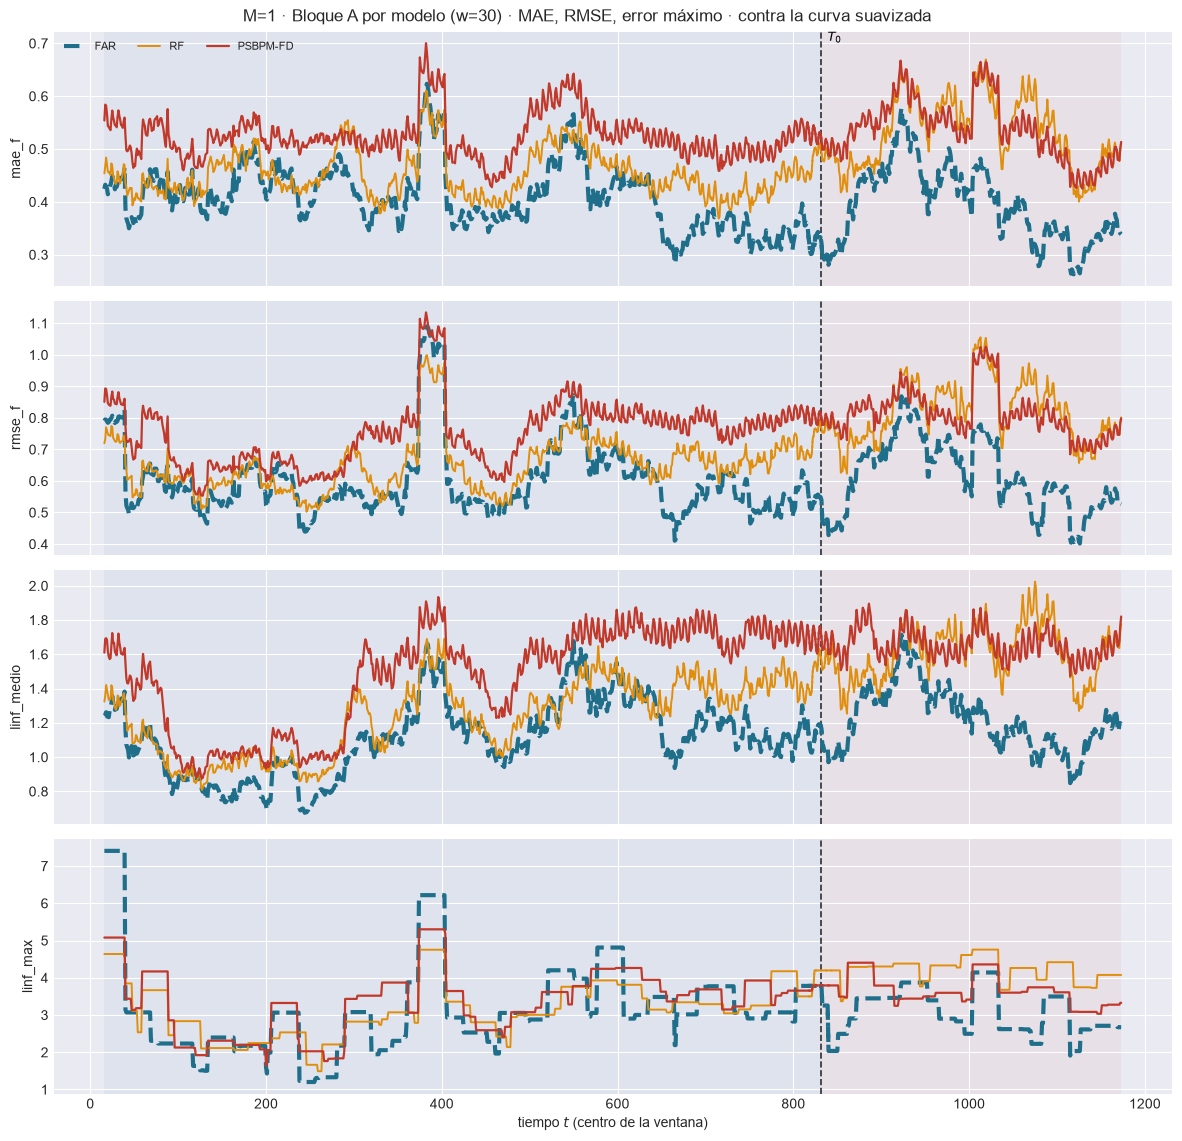

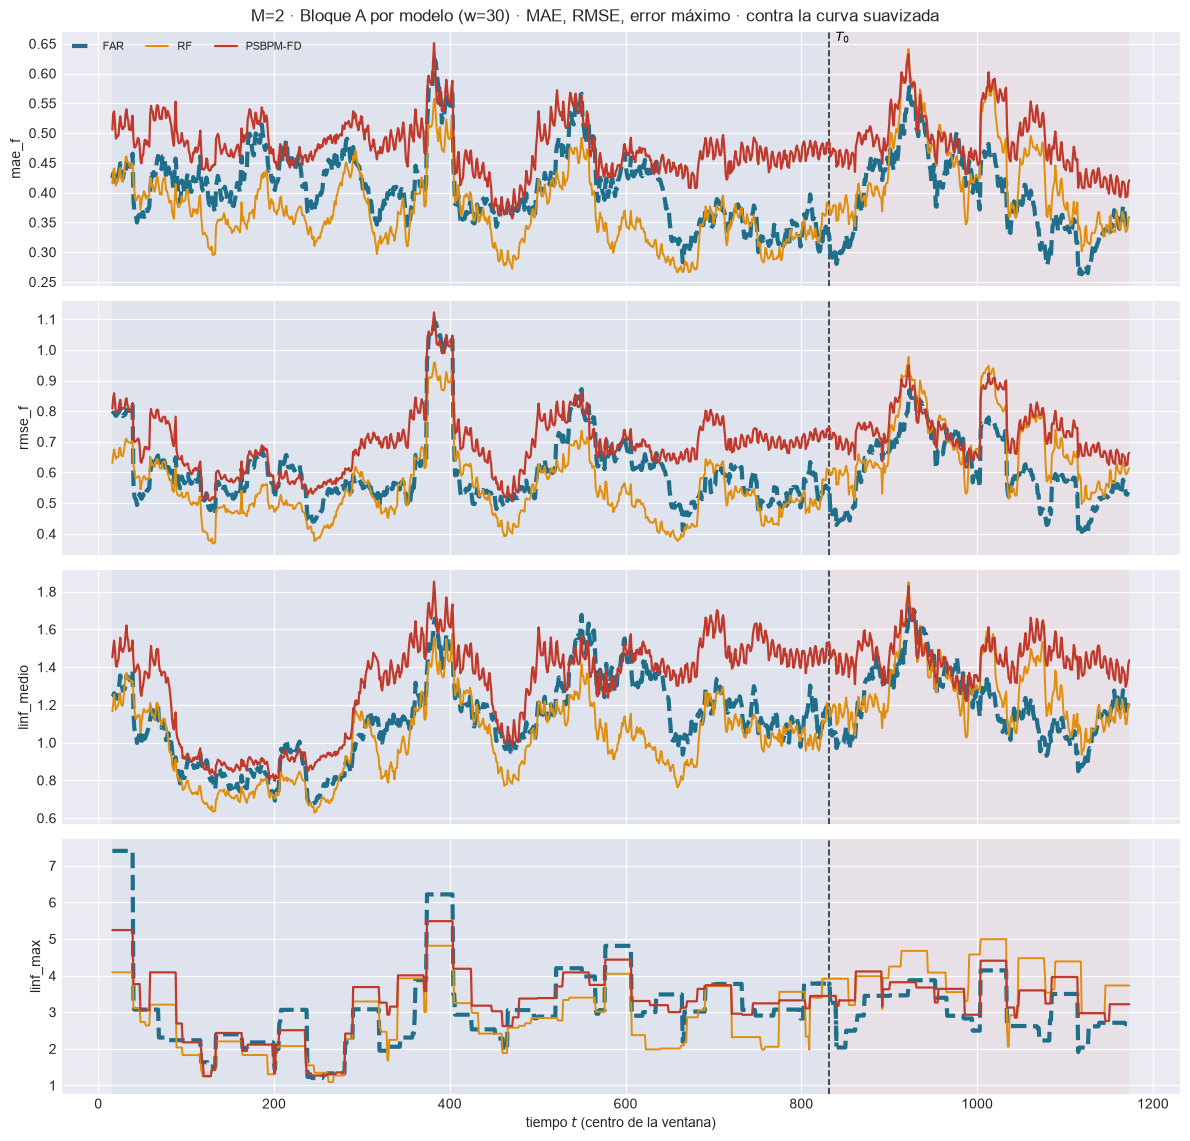

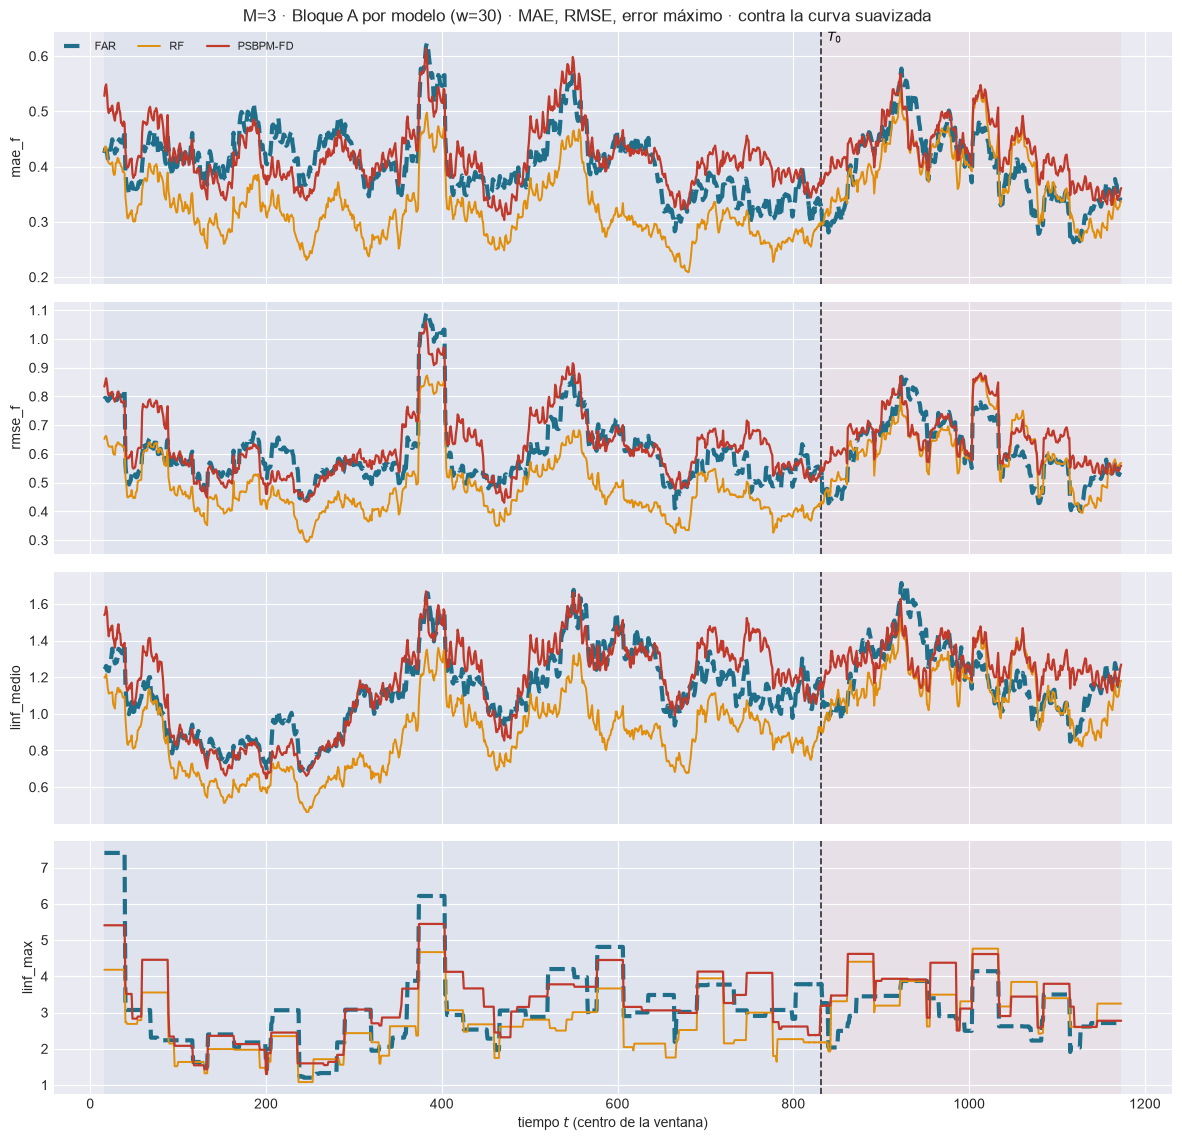

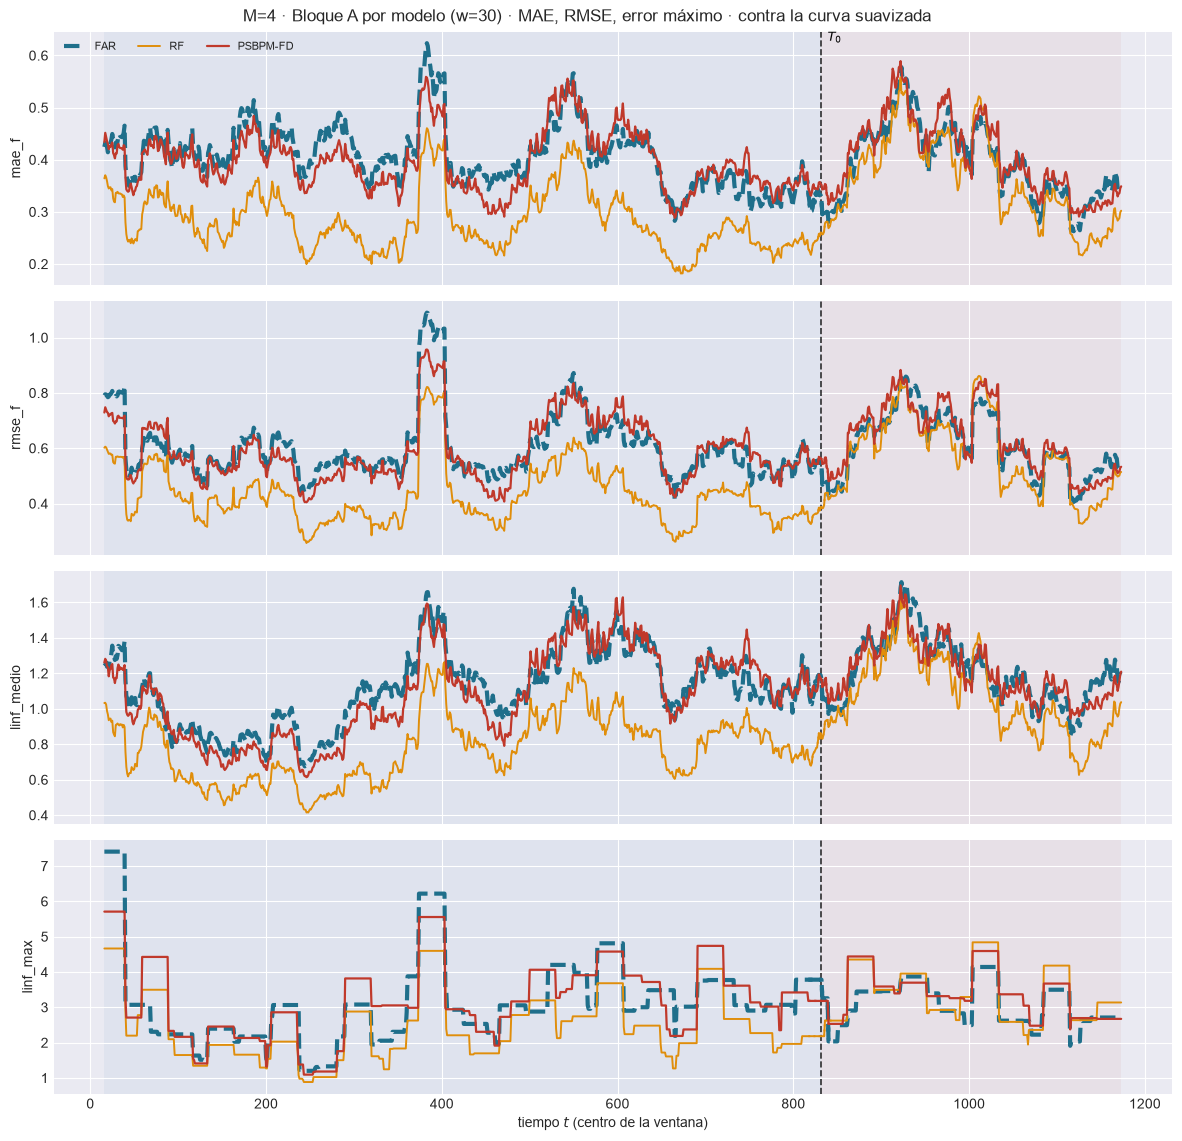

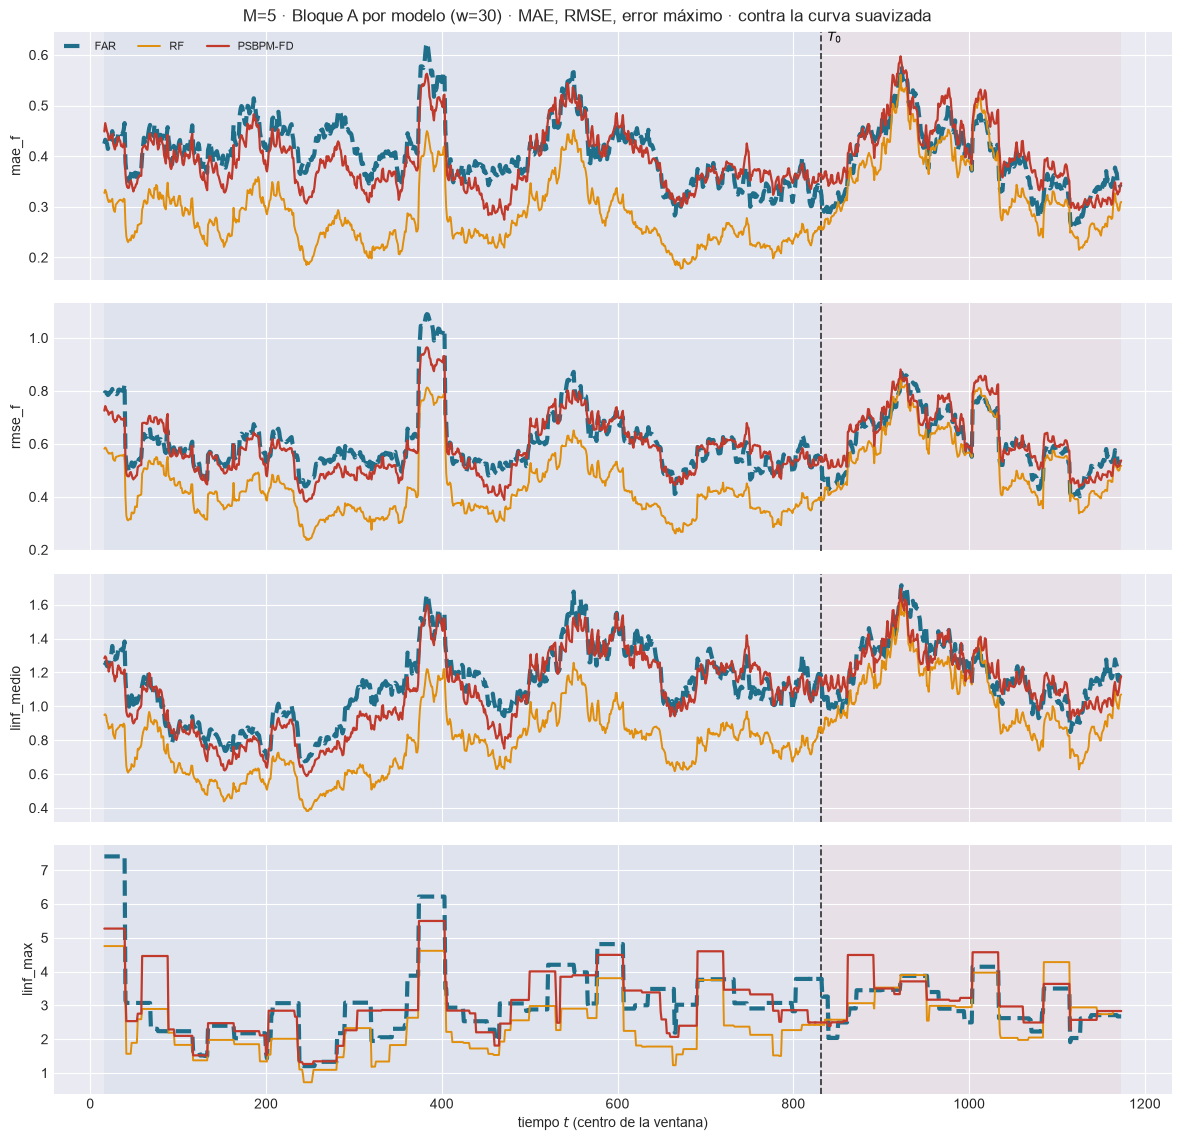

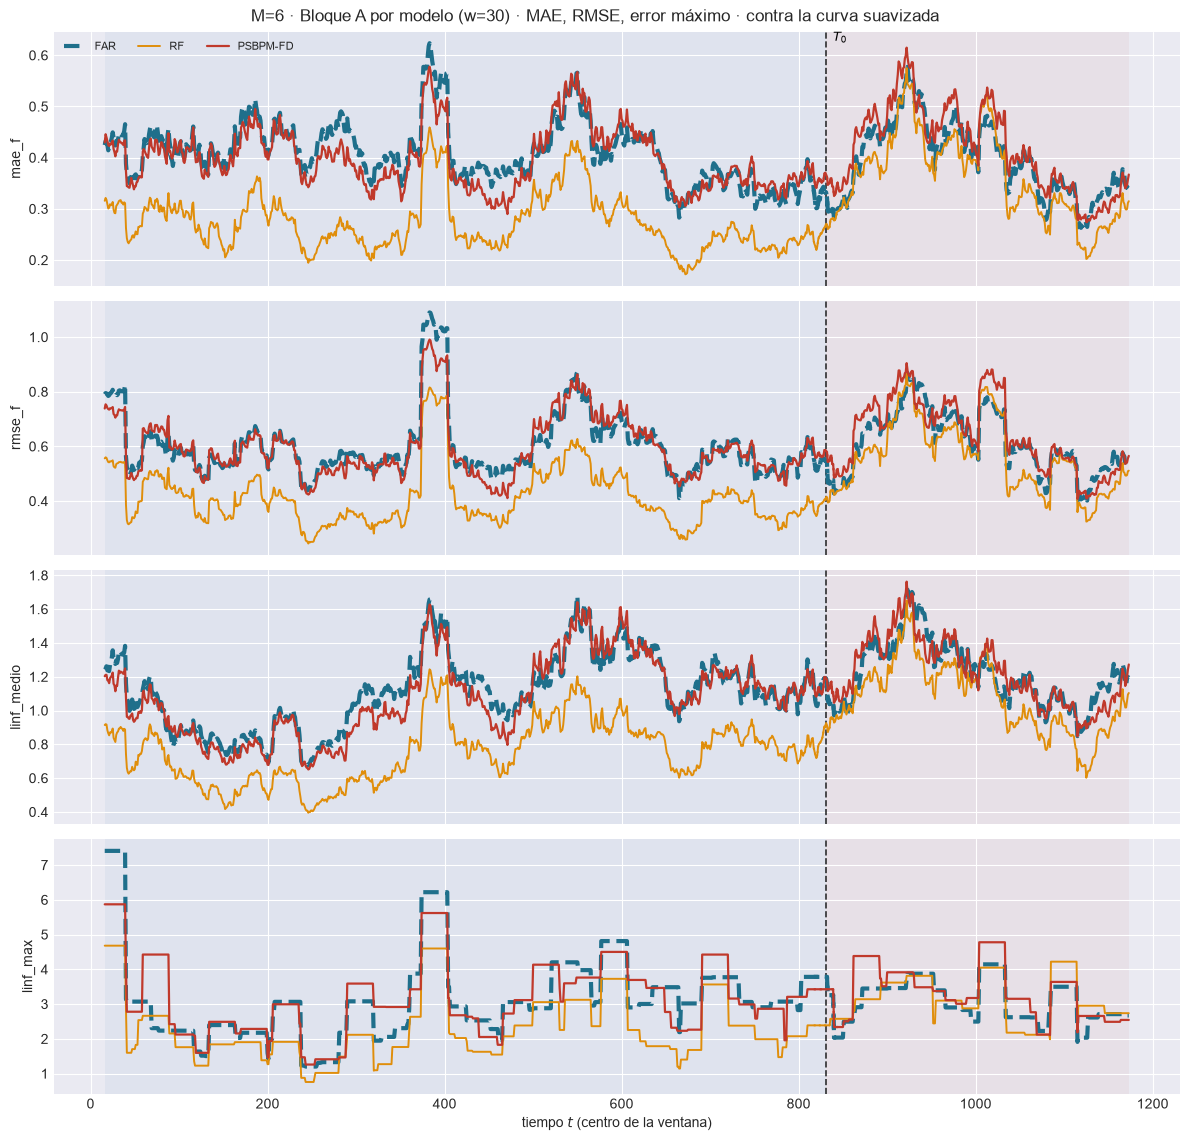

In [8]:
for M in M_OK:
    tablas_modelos(EST[M], DIS, ORIG, PESOS_TAU, PREFIJO)
verificar_cadena_modelos(EST, W_REF)

# Una figura por M; el piso de truncamiento va en las tablas pero no en la figura.
for M in M_OK:
    e = EST[M]
    tw = e["tablas_w"][W_REF]
    tf = tw[tw["modelo"] != PISO].copy()
    tf.attrs["w"] = W_REF
    plot_ventana_movil(
        tf, T0, METRICAS_A_COLS, columna_grupo="modelo", estilos=ESTILOS_MODELOS,
        title=f"M={M} · Bloque A por modelo (w={W_REF}) · MAE, RMSE, error máximo · contra la curva suavizada",
        save_path=str(e["paths"]["out_report"] / f"{PREFIJO + 8}_ventana_bloqueA_modelos_w{W_REF}.png"),
        verbose=False)
    plt.show()

## 5. Bloque B: intervalos, sólo FAR y PSBPM-FD

Las **mismas cuatro cifras** que `30_04` —Winkler, cobertura simultánea,
cobertura puntual y MPIW— sobre la misma ventana móvil.

La diferencia con el Bloque A es a qué modelos aplica. El FAR **no** es un
algoritmo de predicción puntual: es un modelo, $X_{t+1}=\rho(X_t)+\varepsilon$,
de modo que su intervalo a un paso sale de su propia especificación y no de un
procedimiento adosado. El PSBPM-FD tiene su predictiva muestreada. El RF no
es un modelo de probabilidad: rellenarle una banda
gaussiana de residuos dentro de muestra lo haría parecer artificialmente
angostas y decidiría la comparación por el supuesto, no por el método.

In [9]:
for M in M_OK:
    e = EST[M]
    construir_bandas(e, DIS, ORIG, IC_POR_TAU, IC_CORRECCION_ESTIMACION, IC_PSBP_TAMBIEN_GAUSSIANA)
    B_df = tabla_bloque_B(e, DIS, ORIG)
    display(B_df.loc["test"].style
            .format({"winkler": "{:.4f}", "picp": "{:.4f}", "ee_picp": "{:.4f}", "ace": "{:+.4f}",
                     "mpiw": "{:.4f}", "picp_simultaneo": "{:.4f}"})
            .background_gradient(subset=["winkler"], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque B, bloque de PRUEBA · PRIMARIA: winkler · nivel nominal {NIVEL:.0%}"))

M=1  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


M=2  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


M=3  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


M=4  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


M=5  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


M=6  kn=10  correccion=1.0060  sigma_eps(tau) del FAR: min=0.2262 max=1.2398 (razon 5.48)


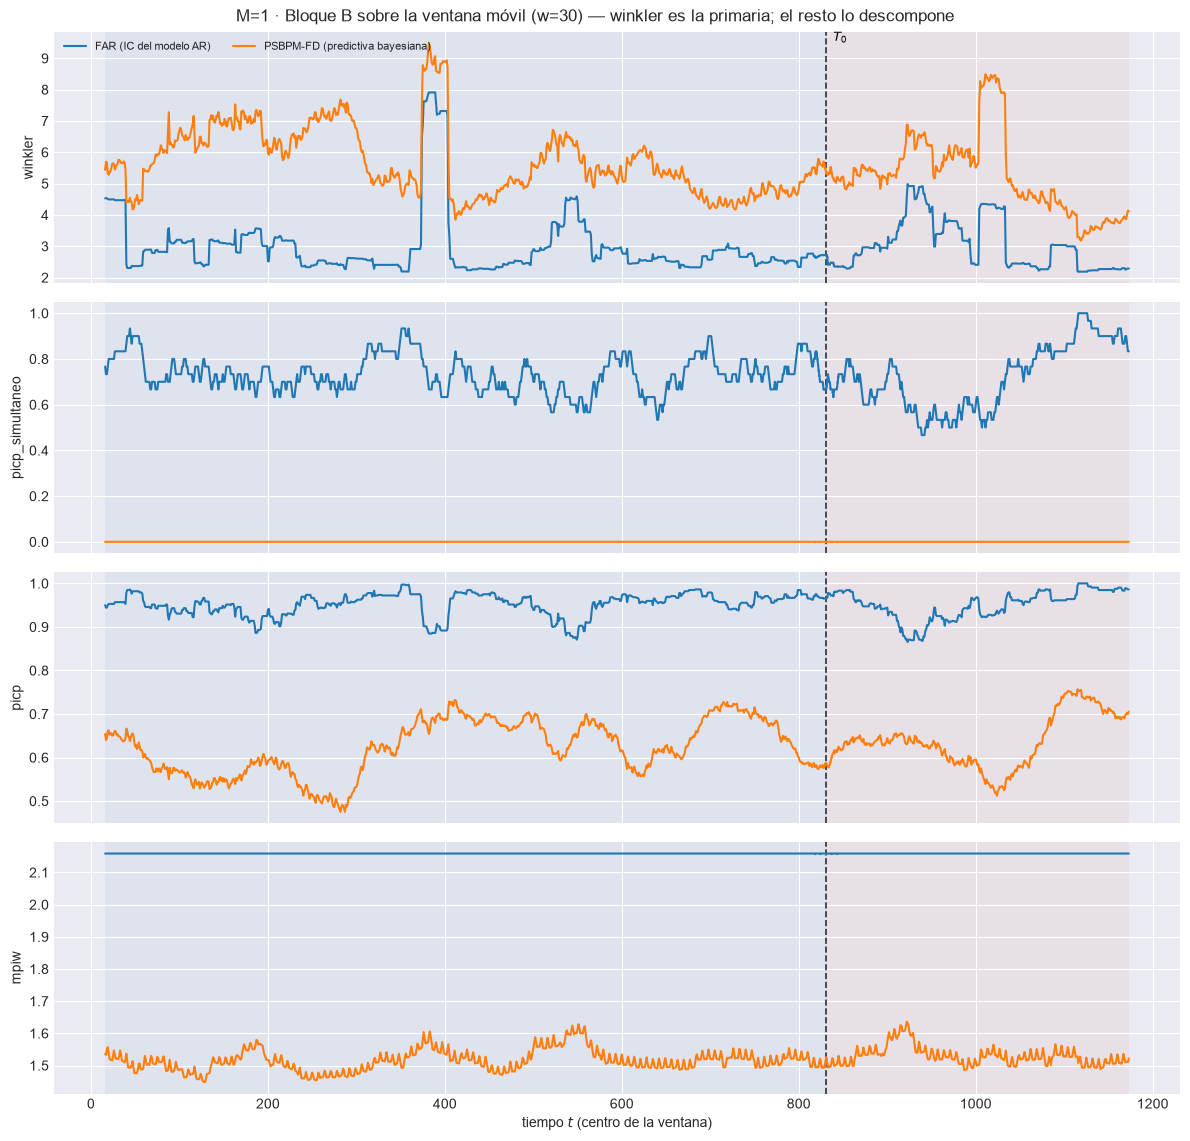

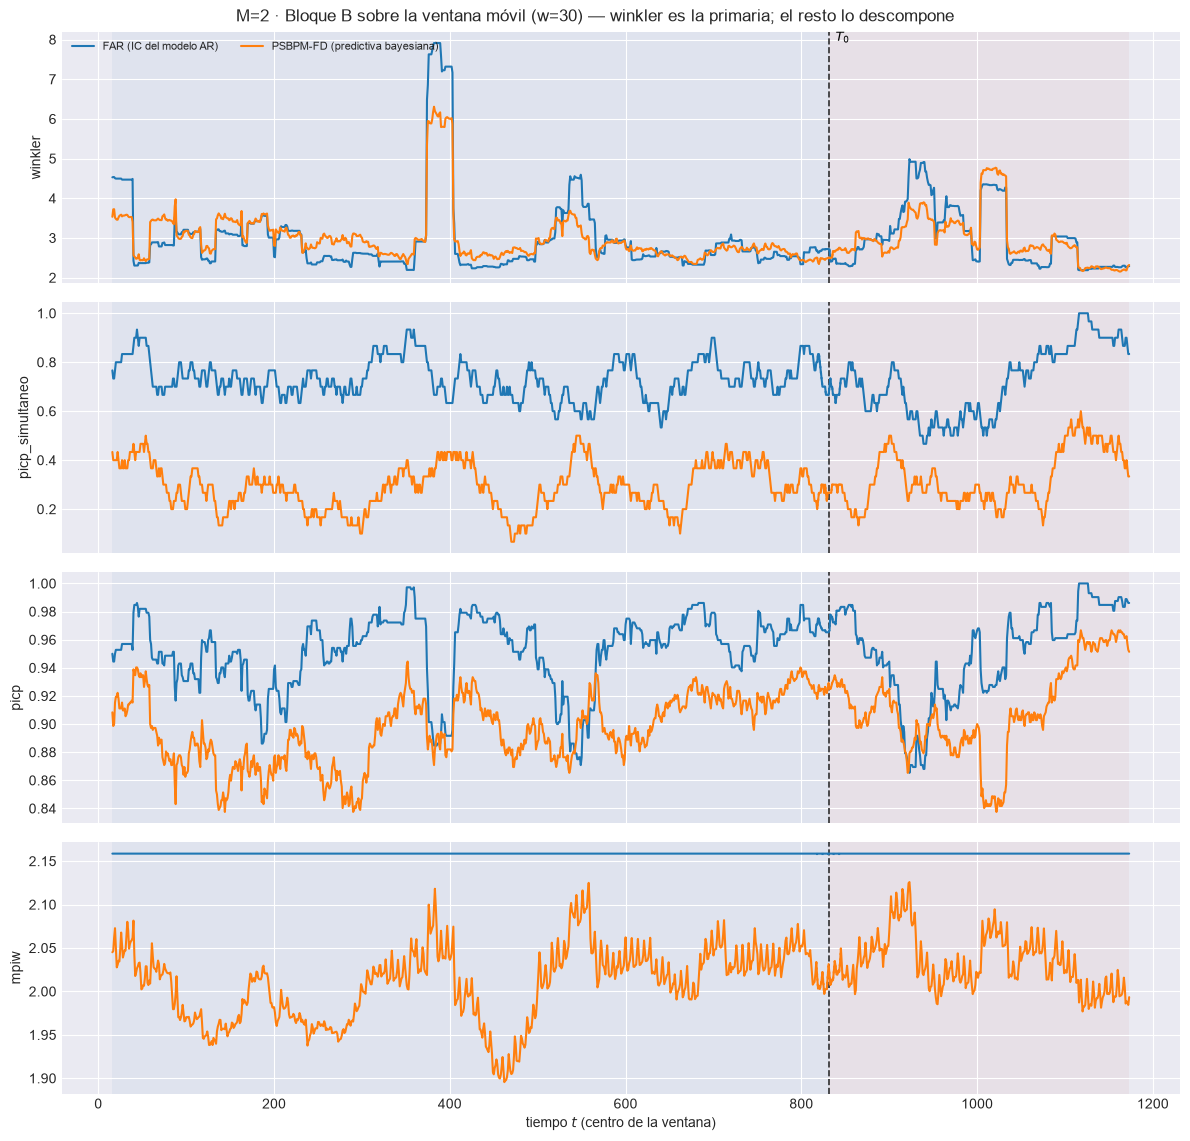

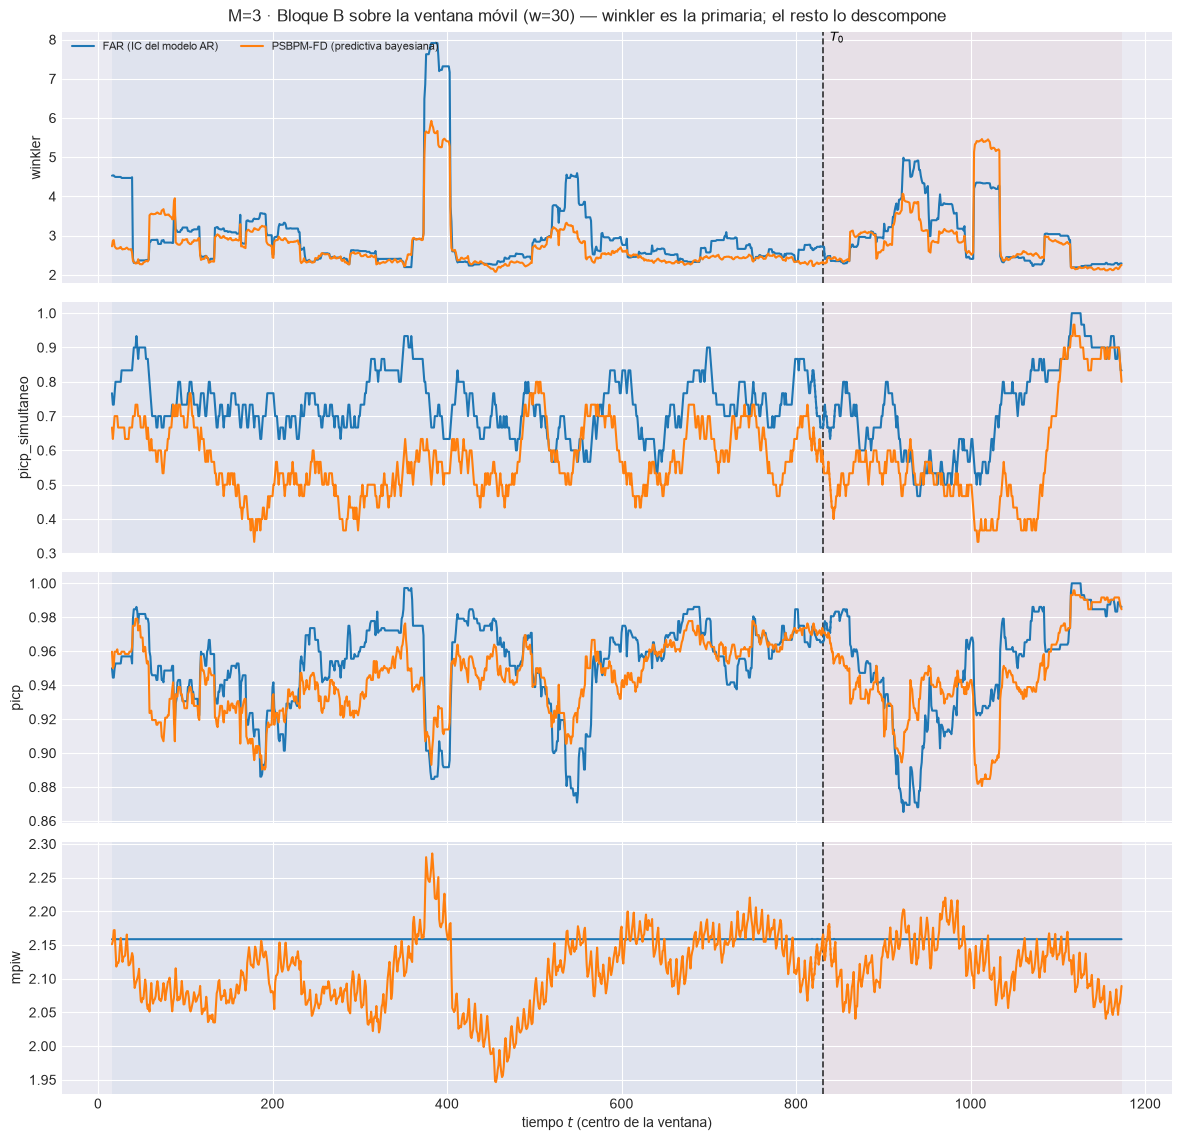

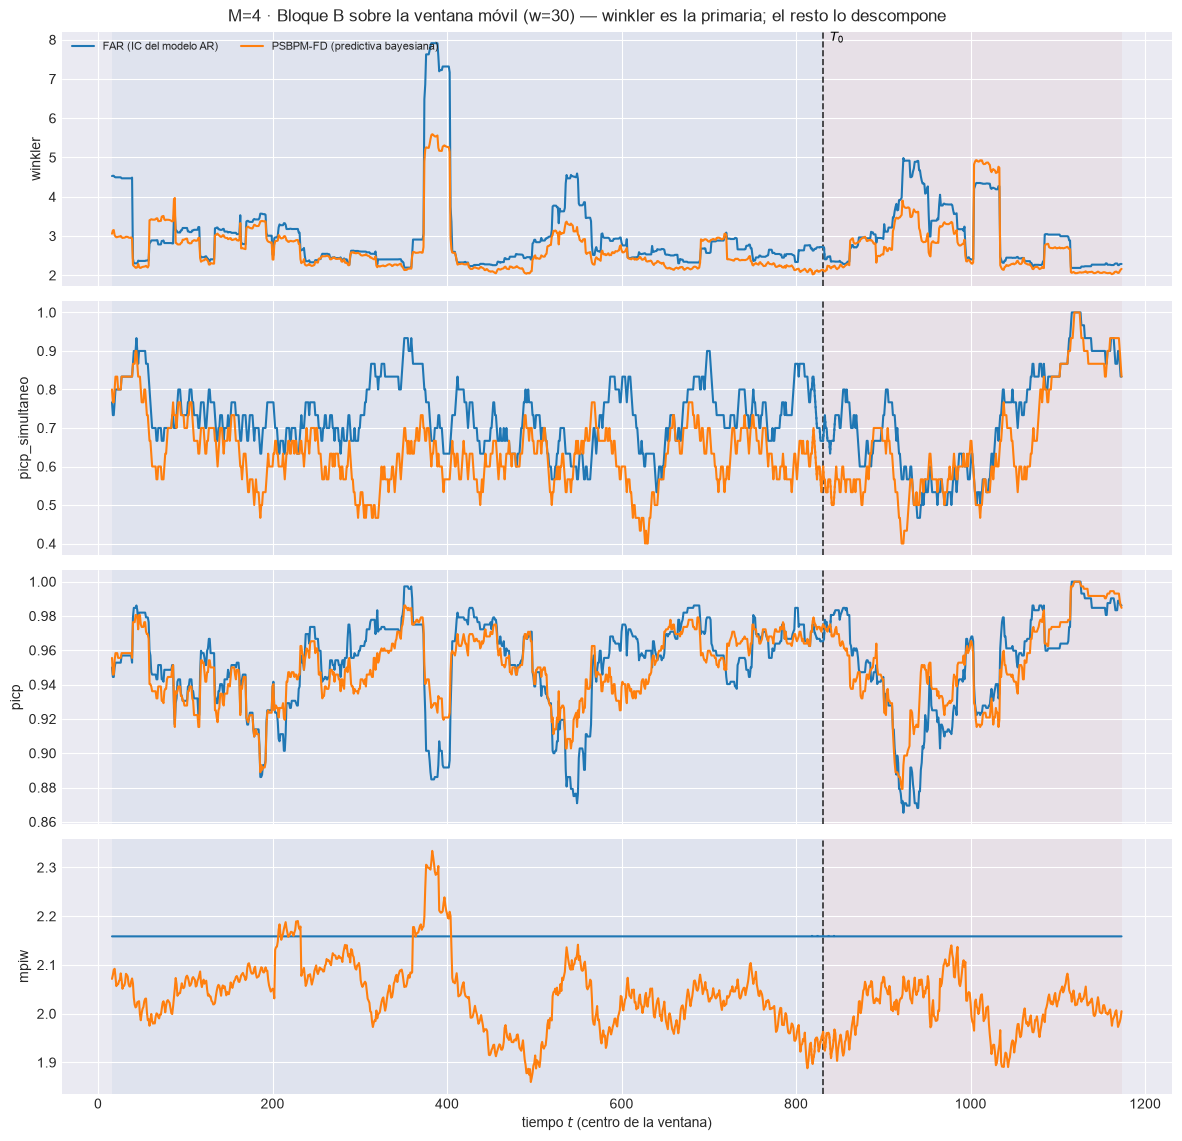

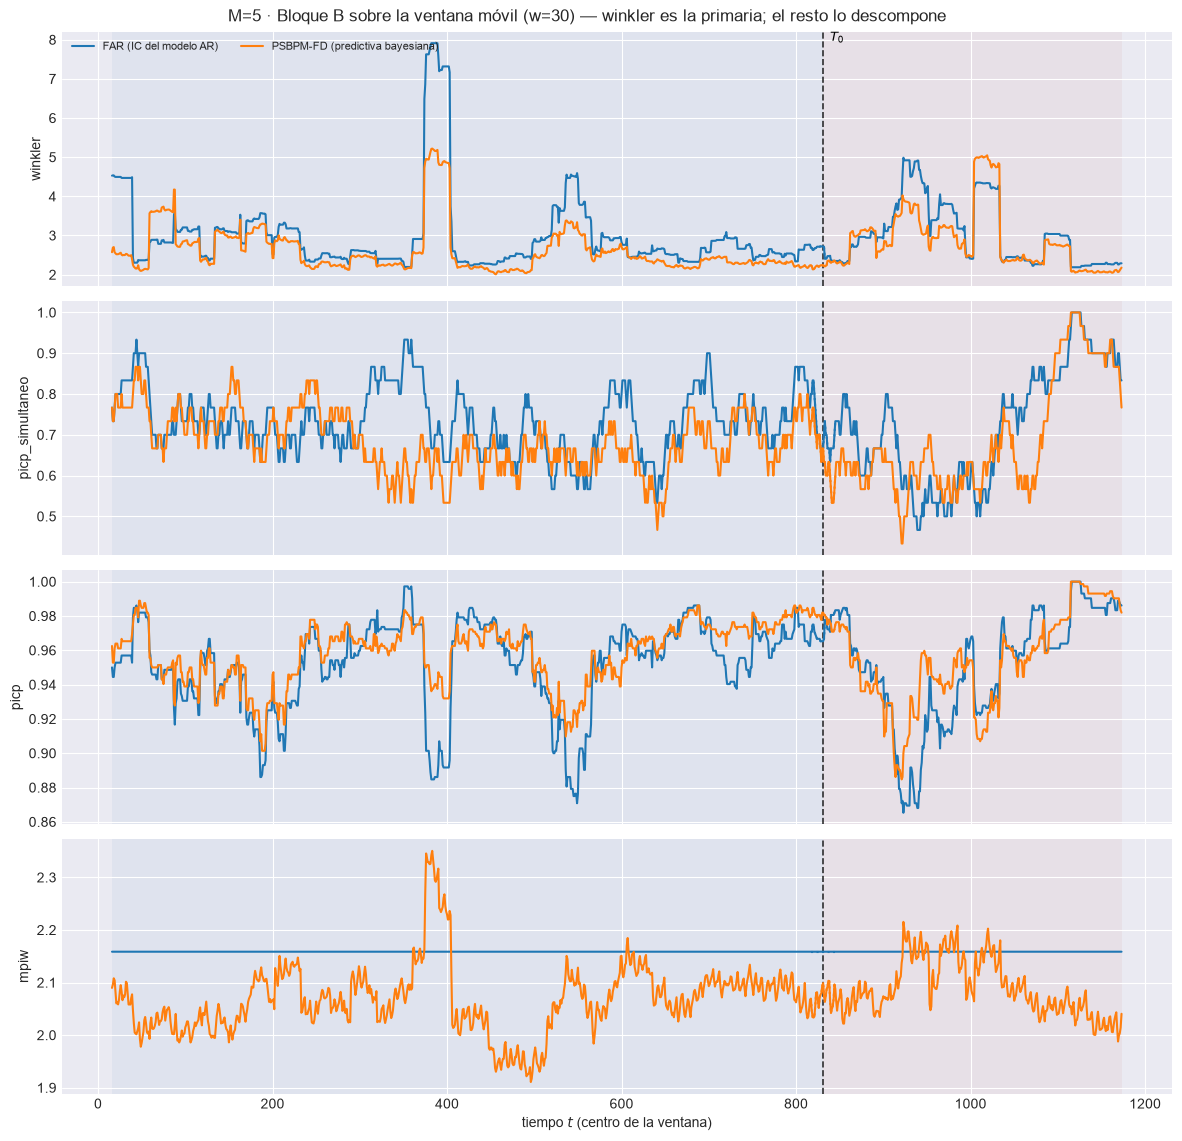

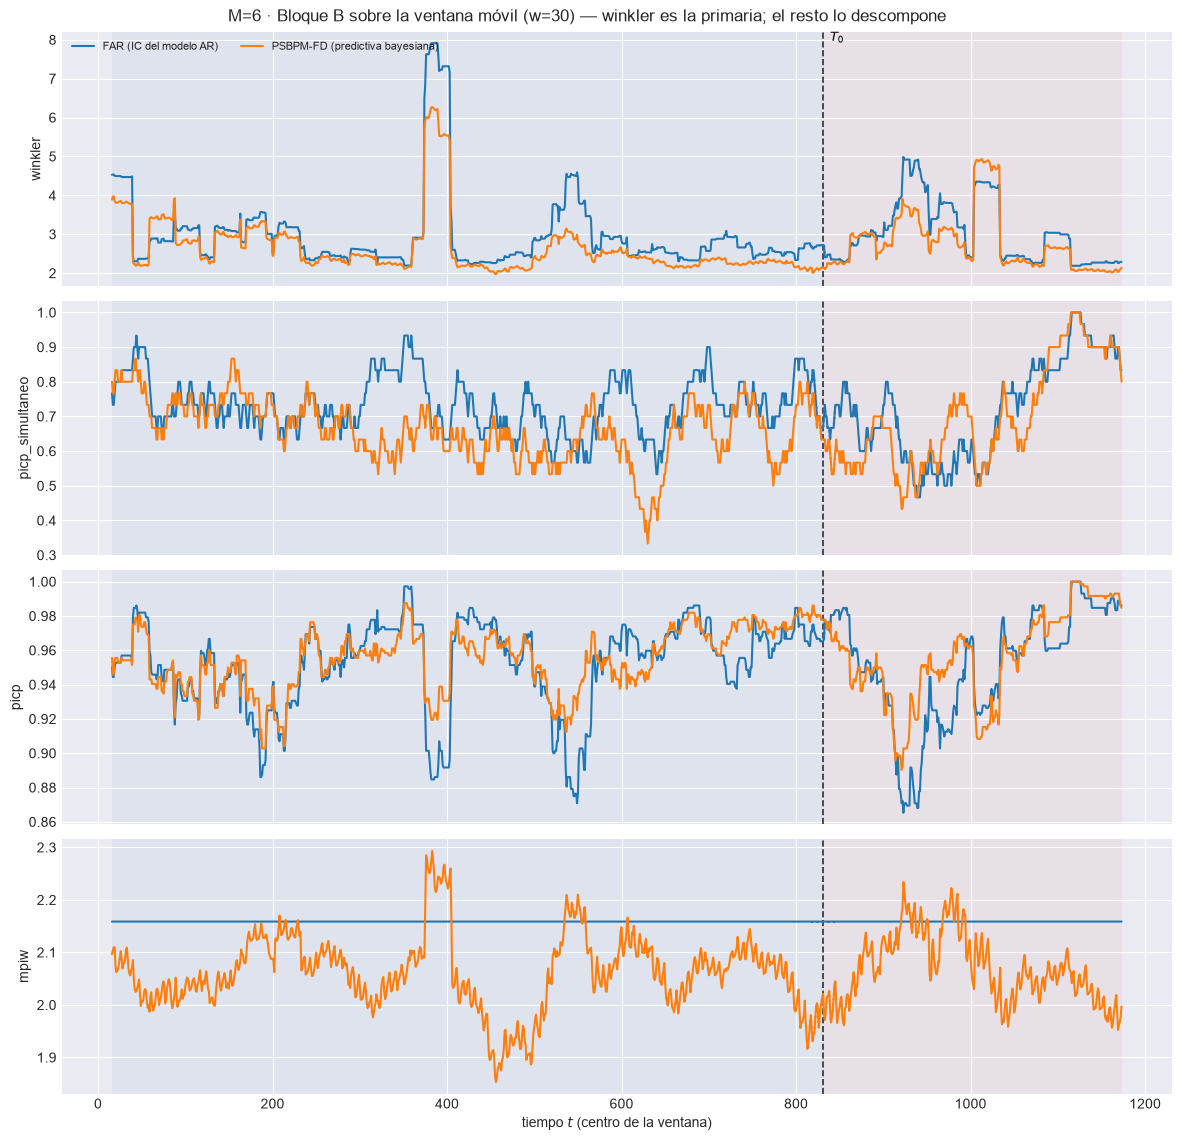

In [10]:
# Winkler sobre la ventana móvil y su descomposición: dice CUÁNDO falla la banda, no sólo cuánto.
for M in M_OK:
    e = EST[M]
    vb = ventana_bloque_B(e, DIS, ORIG, PESOS_TAU, PREFIJO)
    plot_ventana_movil(
        vb, T0, ["winkler", "picp_simultaneo", "picp", "mpiw"], columna_grupo="banda",
        title=f"M={M} · Bloque B sobre la ventana móvil (w={W_REF}) — winkler es la primaria; el resto lo descompone",
        save_path=str(e["paths"]["out_report"] / f"81_ventana_bloqueB_w{W_REF}.png"), verbose=False)
    plt.show()

## 6. Bloque A: quién gana cada ventana, y por cuánto

Dos lecturas distintas y complementarias sobre la misma tabla de ventana:

1. **% de ventanas ganadas** — para cada ventana se marca el modelo con el
   valor más bajo de la métrica. Es una lectura más dura que el promedio: un
   modelo puede tener mejor promedio y ganar pocas ventanas si pierde por poco
   muchas veces y gana por mucho unas pocas.
2. **Cuánto mejor** — la razón de cada modelo contra el mejor de la ventana y
   contra el FAR, la referencia lineal.

Ambas se calculan sobre las ventanas que **no cruzan $T_0$**.

M,1,2,3,4,5,6
modelo,,,,,,
FAR,100.0%,76.5%,46.3%,10.4%,7.9%,10.7%
PSBPM-FD,0.0%,0.0%,1.5%,1.8%,0.0%,0.0%
RF,0.0%,23.5%,52.1%,87.8%,92.1%,89.3%


M,1,2,3,4,5,6
modelo,,,,,,
FAR,1.000,1.018,1.056,1.115,1.126,1.115
PSBPM-FD,1.373,1.267,1.159,1.146,1.176,1.168
RF,1.366,1.108,1.037,1.006,1.003,1.004


M,1,2,3,4,5,6
modelo,,,,,,
FAR,100.0%,75.6%,40.9%,18.0%,9.5%,12.2%
PSBPM-FD,0.0%,3.7%,2.7%,2.4%,0.0%,0.0%
RF,0.0%,20.7%,56.4%,79.6%,90.5%,87.8%


M,1,2,3,4,5,6
modelo,,,,,,
FAR,1.000,1.017,1.058,1.098,1.123,1.115
PSBPM-FD,1.342,1.240,1.145,1.129,1.155,1.157
RF,1.356,1.135,1.044,1.009,1.002,1.004


M,1,2,3,4,5,6
modelo,,,,,,
FAR,99.7%,62.8%,27.4%,6.1%,4.3%,4.6%
PSBPM-FD,0.0%,2.1%,0.0%,2.4%,0.3%,0.9%
RF,0.3%,35.1%,72.6%,91.5%,95.4%,94.5%


M,1,2,3,4,5,6
modelo,,,,,,
FAR,1.000,1.029,1.094,1.160,1.174,1.156
PSBPM-FD,1.379,1.241,1.160,1.154,1.165,1.160
RF,1.343,1.078,1.025,1.003,1.001,1.002


M,1,2,3,4,5,6
modelo,,,,,,
FAR,88.4%,88.7%,64.0%,60.4%,47.9%,45.4%
PSBPM-FD,11.6%,10.1%,1.2%,19.8%,17.1%,17.1%
RF,0.0%,1.2%,34.8%,19.8%,35.1%,37.5%


M,1,2,3,4,5,6
modelo,,,,,,
FAR,1.013,1.007,1.019,1.022,1.065,1.058
PSBPM-FD,1.225,1.190,1.214,1.137,1.158,1.151
RF,1.420,1.336,1.180,1.119,1.070,1.076


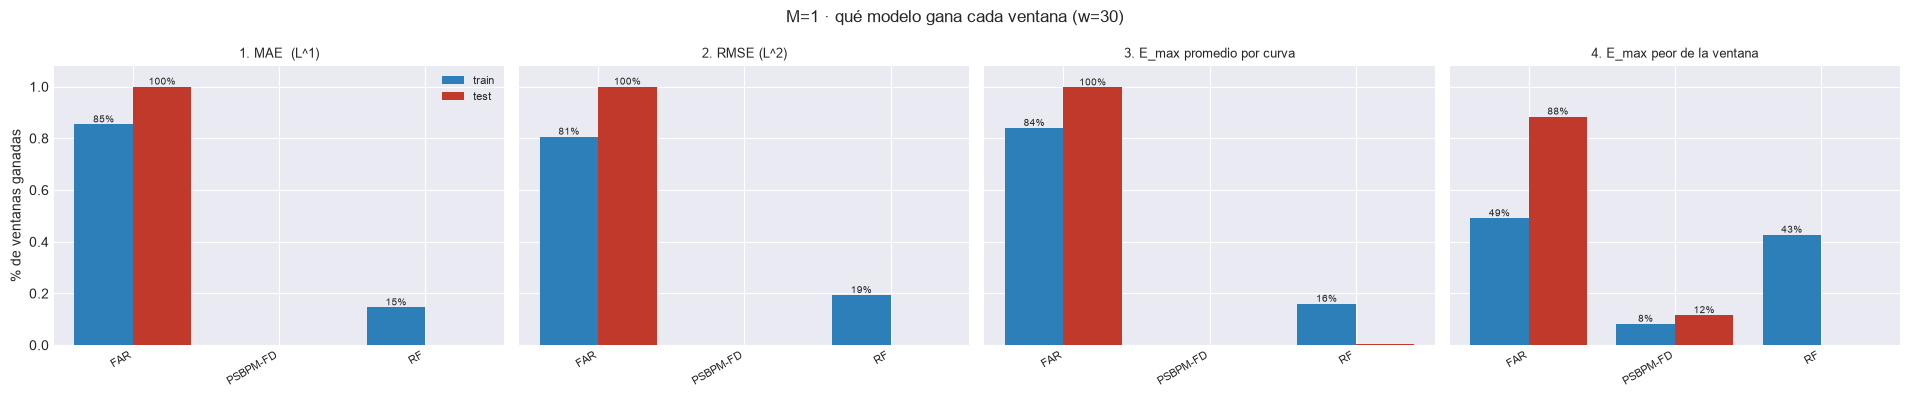

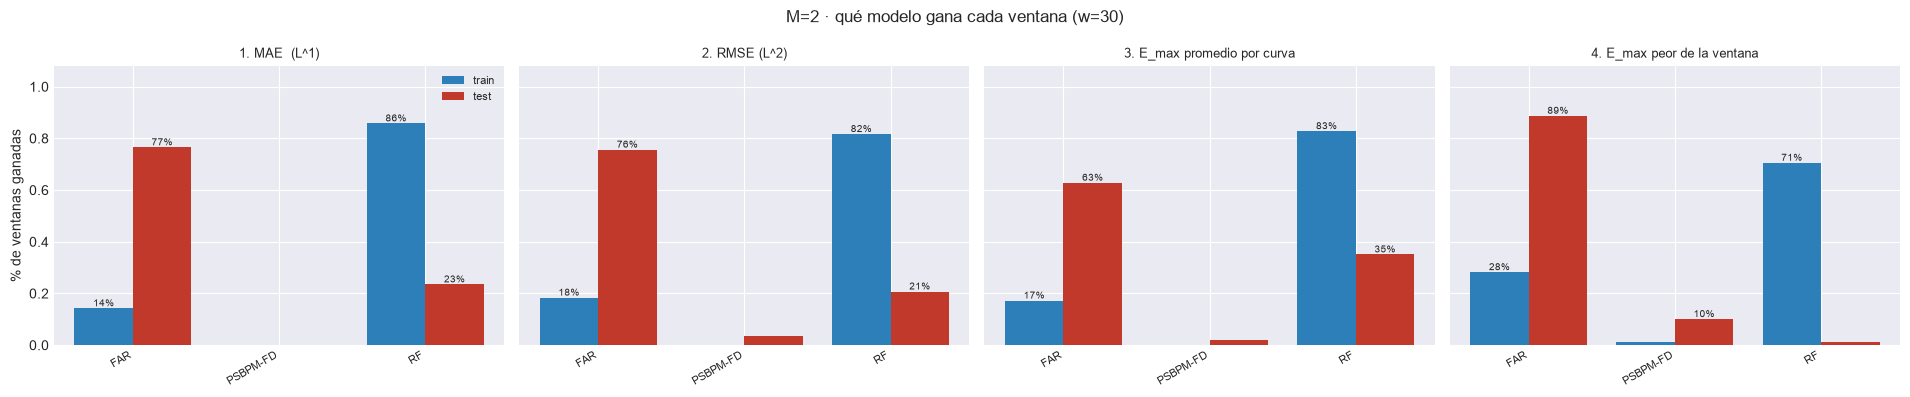

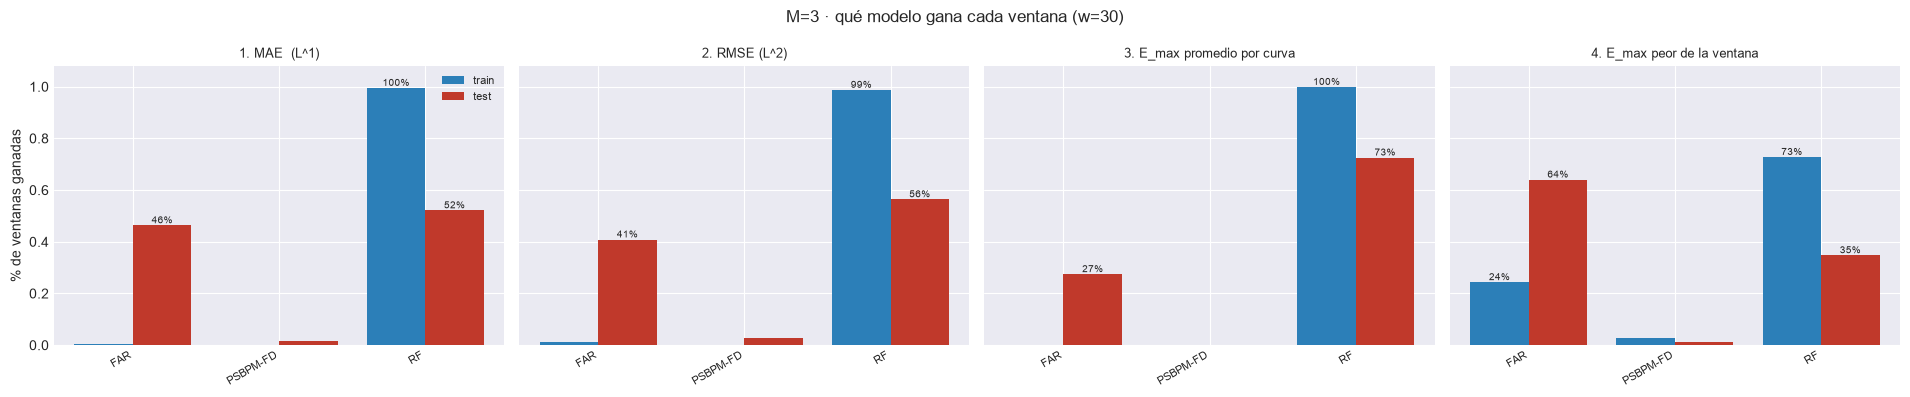

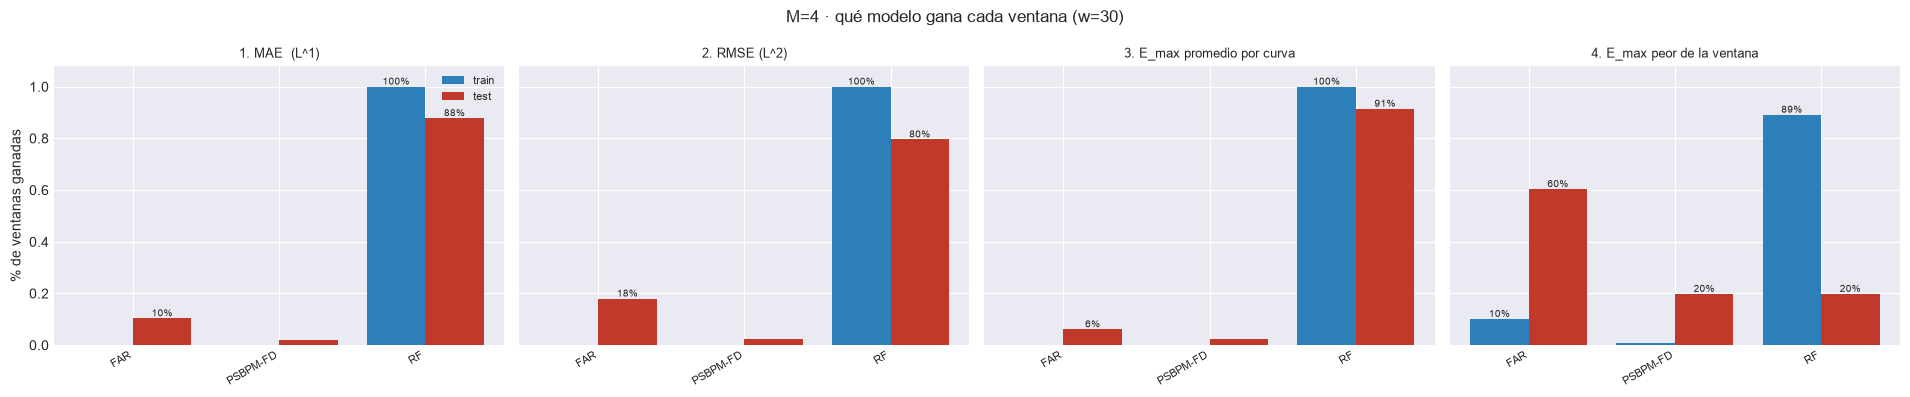

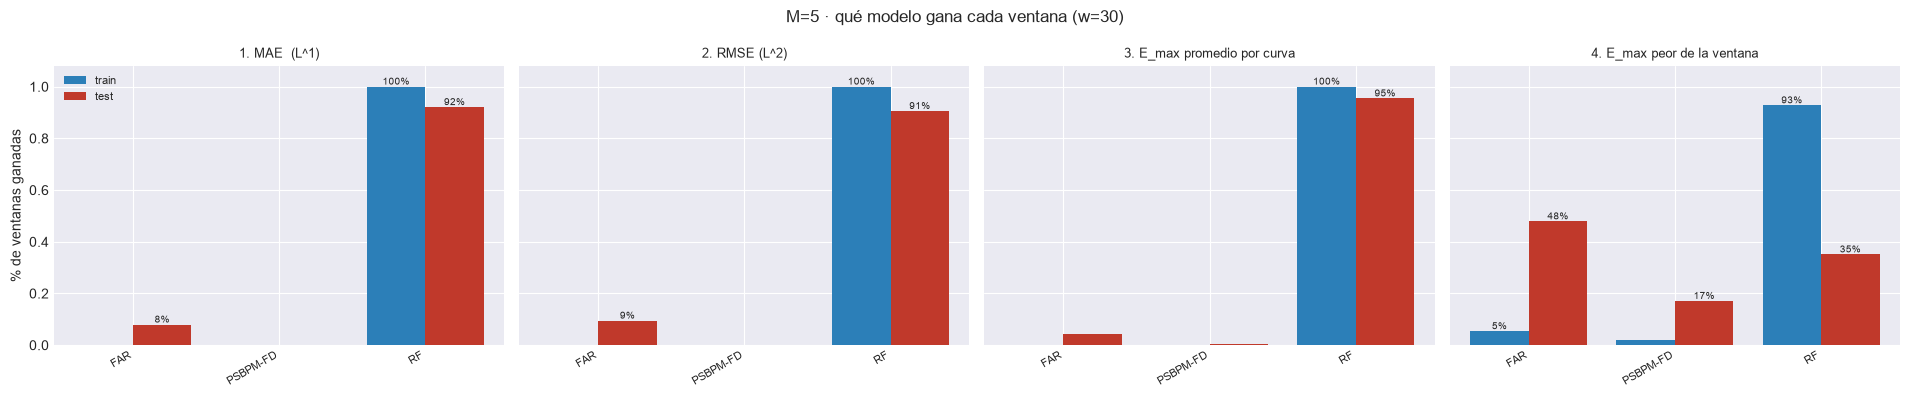

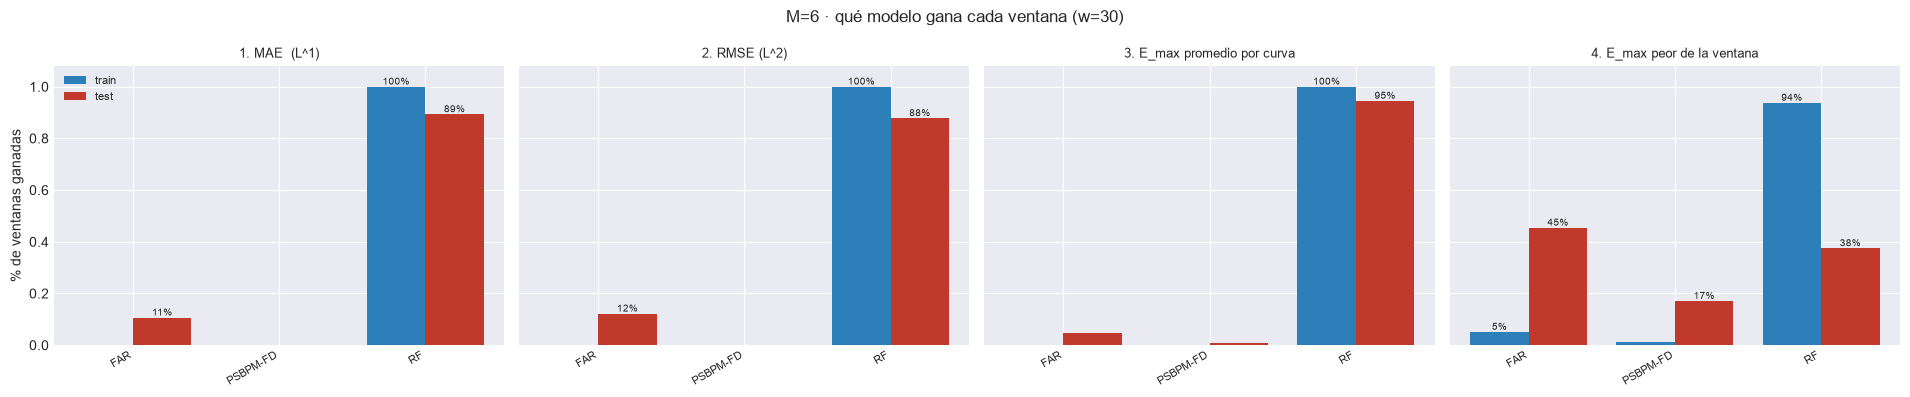

In [11]:
gana_A, rel_A = ganadores_por_ventana(EST, "ventana_df", "modelo", METRICAS_A, NIVEL, excluir=(PISO,))
gana_A.to_csv(PATH_BARRIDO / "96_ganador_ventana_bloqueA.csv", index=False)
rel_A.to_csv(PATH_BARRIDO / "96_razones_bloqueA.csv", index=False)

for etiqueta, _col in METRICAS_A:
    for tabla, v, fmt, cmap, cap in (
            (gana_A, "pct_ventanas_ganadas", "{:.1%}", "RdYlGn",
             f"{etiqueta} · % de ventanas de PRUEBA ganadas (w={W_REF}, sin cruzar T0)"),
            (rel_A, "razon_vs_mejor", "{:.3f}", "RdYlGn_r",
             f"{etiqueta} · razón contra el MEJOR de cada ventana (test) · 1.000 = gana siempre")):
        piv = (tabla[(tabla.metrica == etiqueta) & (tabla.bloque == "test")]
               .pivot(index="modelo", columns="M", values=v))
        display(piv.style.format(fmt, na_rep="-").background_gradient(cmap=cmap, axis=None).set_caption(cap))

for M in M_OK:
    plot_ganador_modelo(gana_A, M, METRICAS_A, W_REF,
                        EST[M]["paths"]["out_report"] / f"{PREFIJO + 8}_ganador_ventana_bloqueA.png")
    plt.show()

## 7. Bloque B: quién gana cada ventana, y por cuánto

La misma lectura de §6, restringida a las series que **tienen un mecanismo de
intervalo propio**: el FAR —cuyo IC a un paso sale de su propia especificación
$X_{t+1}=\rho(X_t)+\varepsilon$— y el PSBPM-FD —cuya predictiva se muestrea y
cuyos cuantiles empíricos dan la banda—.

El Winkler es la única regla de puntuación propia del bloque, así que es la
que decide quién gana; PICP y MPIW lo descomponen en cobertura y ancho.

In [12]:
# En picp / picp_simultaneo "ganar" es estar más cerca del nominal, no tener el valor más bajo.
gana_B, rel_B = ganadores_por_ventana(EST, "ventana_B", "banda", METRICAS_B, NIVEL)
gana_B.to_csv(PATH_BARRIDO / "97_ganador_ventana_bloqueB.csv", index=False)
rel_B.to_csv(PATH_BARRIDO / "97_razones_bloqueB.csv", index=False)

for etiqueta, col in METRICAS_B:
    piv = (gana_B[(gana_B.metrica == etiqueta) & (gana_B.bloque == "test")]
           .pivot(index="banda", columns="M", values="pct_ventanas_ganadas"))
    crit = "más cerca del nominal" if col.startswith("picp") else "menor es mejor"
    display(piv.style.format("{:.1%}", na_rep="-").background_gradient(cmap="RdYlGn", axis=None)
            .set_caption(f"{etiqueta} · % de ventanas de PRUEBA ganadas (criterio: {crit})"))

M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),0.0%,0.0%,18.0%,0.0%,15.5%,12.5%
PSBPM-FD (predictiva bayesiana),100.0%,100.0%,82.0%,100.0%,84.5%,87.5%


M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),100.0%,66.2%,47.3%,44.2%,50.3%,50.0%
PSBPM-FD (predictiva bayesiana),0.0%,33.8%,52.7%,55.8%,49.7%,50.0%


M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),100.0%,100.0%,89.3%,76.8%,71.6%,65.5%
PSBPM-FD (predictiva bayesiana),0.0%,0.0%,10.7%,23.2%,28.4%,34.5%


M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),100.0%,47.3%,38.1%,12.8%,28.7%,15.9%
PSBPM-FD (predictiva bayesiana),0.0%,52.7%,61.9%,87.2%,71.3%,84.1%


M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),100.0%,83.2%,44.2%,31.7%,29.6%,32.3%
PSBPM-FD (predictiva bayesiana),0.0%,16.8%,55.8%,68.3%,70.4%,67.7%


M,1,2,3,4,5,6
banda,,,,,,
FAR (IC del modelo AR),73.5%,58.8%,38.7%,50.9%,35.7%,30.2%
PSBPM-FD (predictiva bayesiana),26.5%,41.2%,61.3%,49.1%,64.3%,69.8%


## 8. Cuadro resumen: mínimo, máximo y promedio

Igual que en `30_04`: la ventana móvil genera una **serie** por métrica y por
modelo, no una cifra. El resumen muestra los tres números que describen esa
serie —mínimo, máximo y promedio— por bloque train/test, excluyendo las
ventanas que cruzan $T_0$.

El **máximo** es el que no aparece en ninguna tabla de promedios y suele ser el
que decide: un modelo con buen promedio y un máximo muy alto falla feo en
algún tramo, y eso es información distinta de su error típico.

In [13]:
resumen_A = resumen_min_max(EST, "ventana_df", "modelo", METRICAS_A, excluir=(PISO,))
resumen_B = resumen_min_max(EST, "ventana_B", "banda", METRICAS_B)
resumen_A.to_csv(PATH_BARRIDO / "98_resumen_bloqueA_min_max_prom.csv", index=False)
resumen_B.to_csv(PATH_BARRIDO / "99_resumen_bloqueB_min_max_prom.csv", index=False)

for M in M_OK:
    for res, grupo, fmt, nombre in ((resumen_A, "modelo", "{:.6f}", "Bloque A"), (resumen_B, "banda", "{:.4f}", "Bloque B")):
        sub = (res[(res.M == M) & (res.bloque == "test")]
               .set_index(["metrica", grupo])[["minimo", "maximo", "promedio"]])
        display(sub.style.format(fmt).background_gradient(subset=["maximo"], cmap="RdYlGn_r")
                .set_caption(f"M={M} · {nombre} en el TEST · mínimo / máximo / promedio sobre las ventanas (w={W_REF})"))

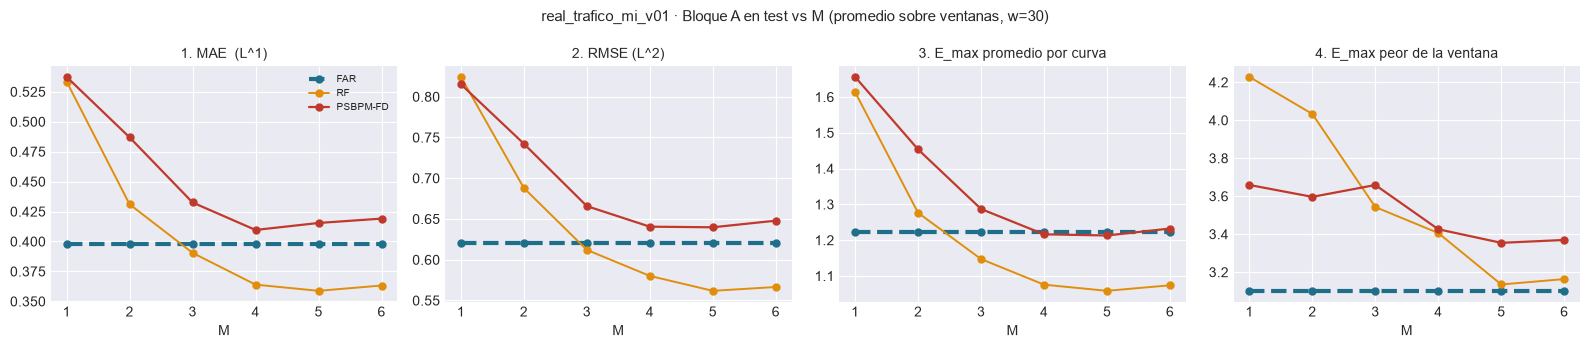

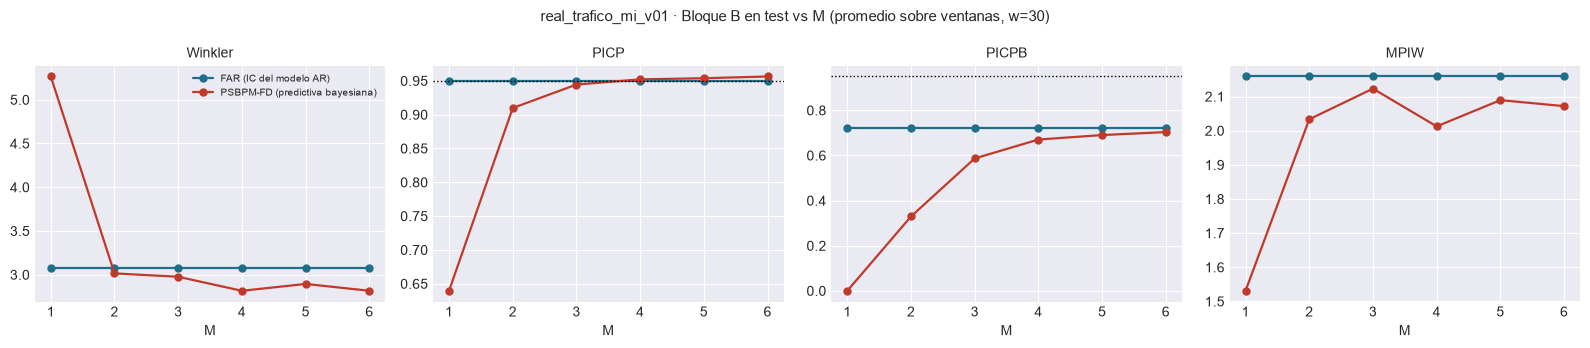

In [14]:
# Las métricas contra M: promedio en test sobre las ventanas, una línea por modelo / banda.
ESTILOS_BANDAS = {G_FAR: dict(color="#1f6f8b"), G_PSG: dict(color="#e08e0b"), G_PSB: dict(color="#c0392b")}

plot_metricas_vs_M(promedio_vs_M(resumen_A, "modelo"), METRICAS_A, ESTILOS_MODELOS,
                   f"{EXPERIMENT_BASE} · Bloque A en test vs M (promedio sobre ventanas, w={W_REF})",
                   save_path=PATH_BARRIDO / f"{PREFIJO + 6}_bloqueA_vs_M.png")
plt.show()
plot_metricas_vs_M(promedio_vs_M(resumen_B, "banda"),
                   [("Winkler", "winkler"), ("PICP", "picp"), ("PICPB", "picp_simultaneo"), ("MPIW", "mpiw")],
                   ESTILOS_BANDAS,
                   f"{EXPERIMENT_BASE} · Bloque B en test vs M (promedio sobre ventanas, w={W_REF})",
                   nominal=NIVEL, save_path=PATH_BARRIDO / f"{PREFIJO + 7}_bloqueB_vs_M.png")
plt.show()

## 9. Intervalos de credibilidad: FAR contra PSBPM-FD, curva a curva

Los promedios de §7 y §8 dicen *cuánto*, no *dónde*. Aquí se eligen los
$N$ orígenes de prueba **mejor** y **peor** predichos según
`METRICA_SEL_IC` ([CONFIG]) y se dibujan las dos bandas superpuestas sobre la
misma curva verdadera.

Es donde se ve la diferencia cualitativa que las cifras agregadas promedian: el
IC del FAR tiene **ancho que no depende del origen** —su $\Sigma_\varepsilon$
es la misma para todo $t$, de modo que sólo hereda la forma de $\tau$— mientras
que la banda del PSBPM-FD sale de los cuantiles de una predictiva que sí cambia
con el estado rezagado.


[M=1] por rmse_f (PSBPM-FD, test): mejores t = [1134, 946, 1130, 905, 850]   ·   peores t = [1019, 1020, 877, 1100, 937]
[M=2] por rmse_f (PSBPM-FD, test): mejores t = [905, 1130, 1155, 1099, 1127]   ·   peores t = [1019, 1100, 877, 916, 937]
[M=3] por rmse_f (PSBPM-FD, test): mejores t = [905, 1155, 891, 1127, 1099]   ·   peores t = [1019, 877, 1100, 916, 909]
[M=4] por rmse_f (PSBPM-FD, test): mejores t = [975, 1046, 835, 923, 905]   ·   peores t = [1019, 877, 1100, 916, 980]
[M=5] por rmse_f (PSBPM-FD, test): mejores t = [905, 975, 923, 1164, 1130]   ·   peores t = [1019, 877, 1100, 980, 916]
[M=6] por rmse_f (PSBPM-FD, test): mejores t = [975, 1046, 1155, 903, 905]   ·   peores t = [1019, 877, 1100, 916, 915]


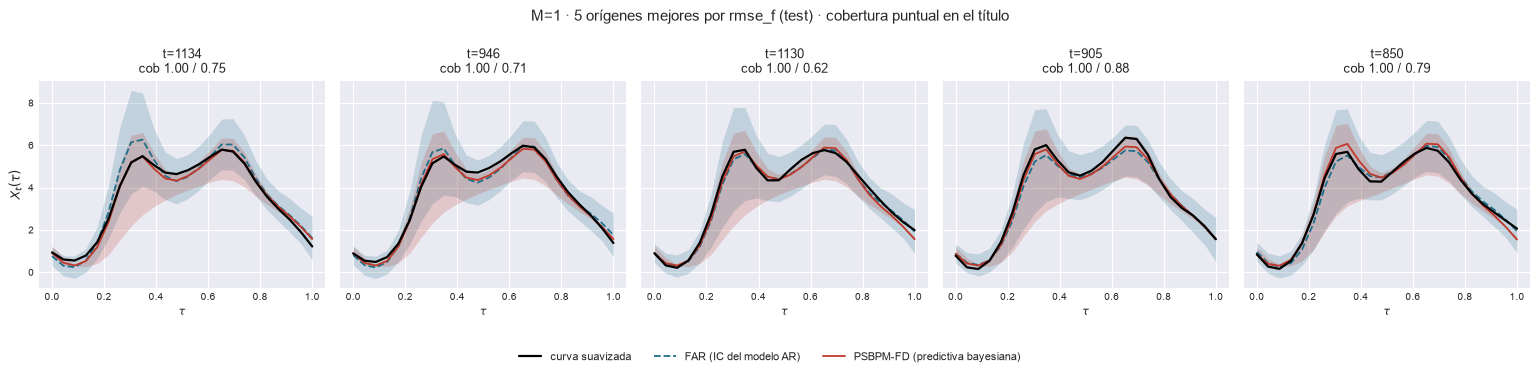

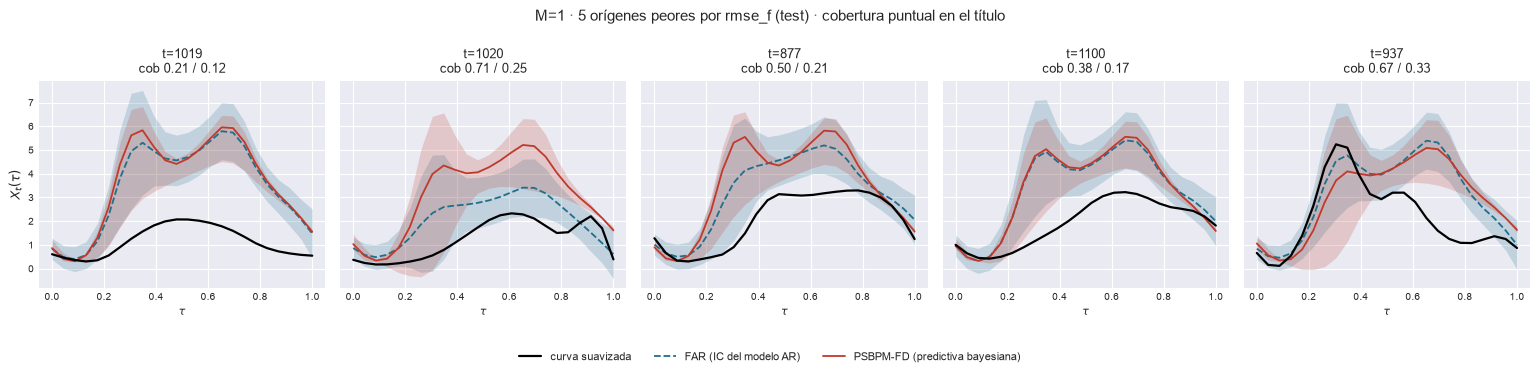

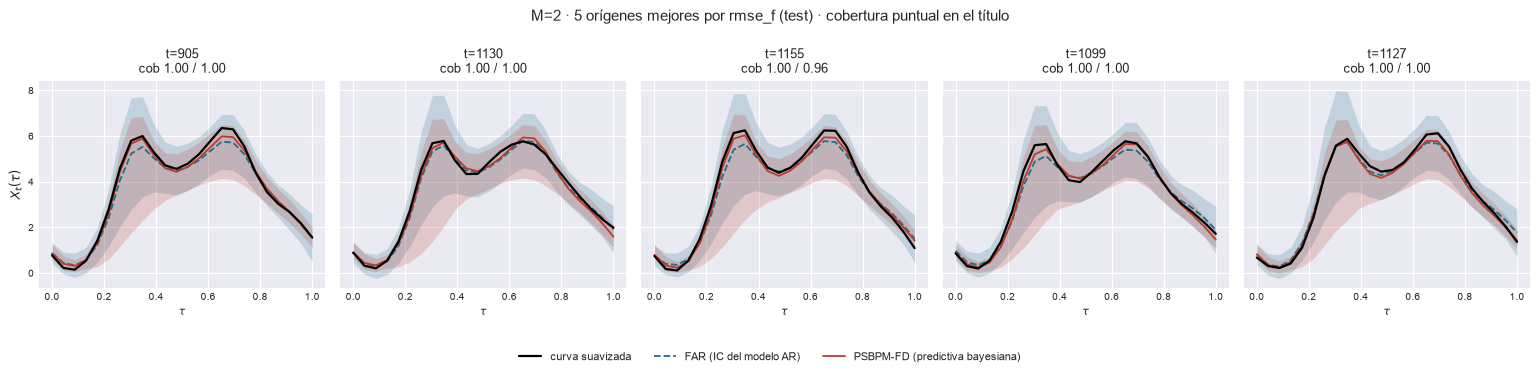

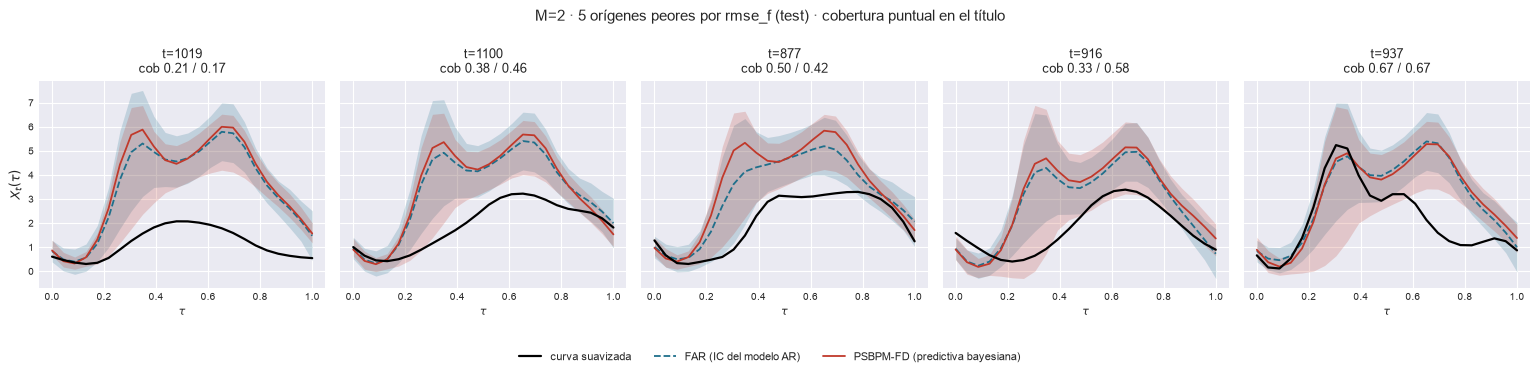

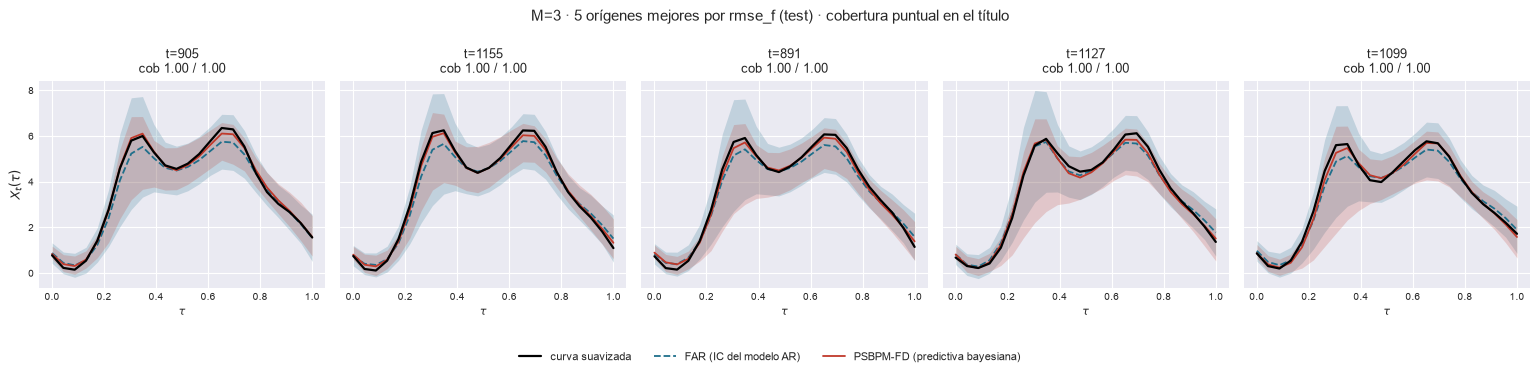

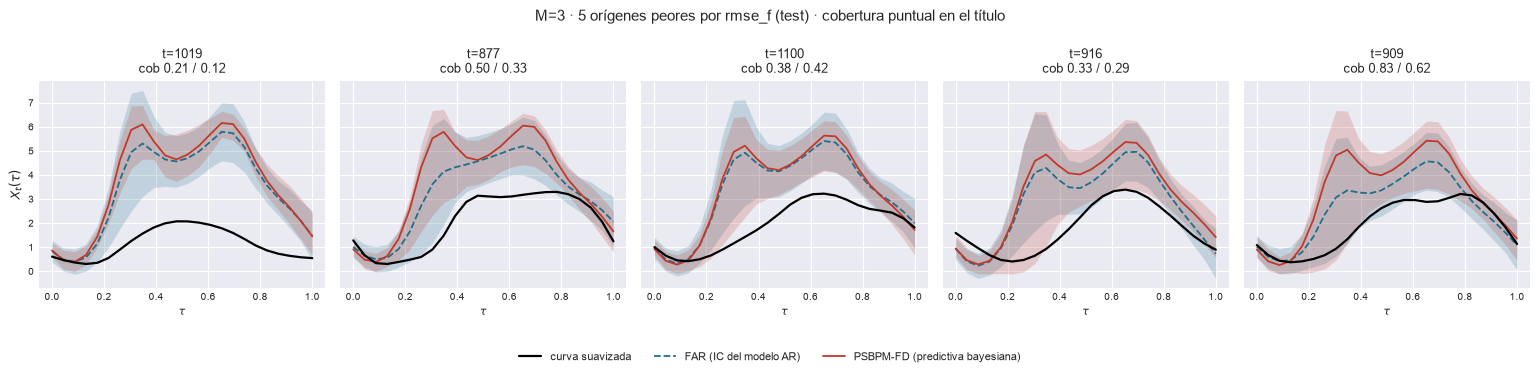

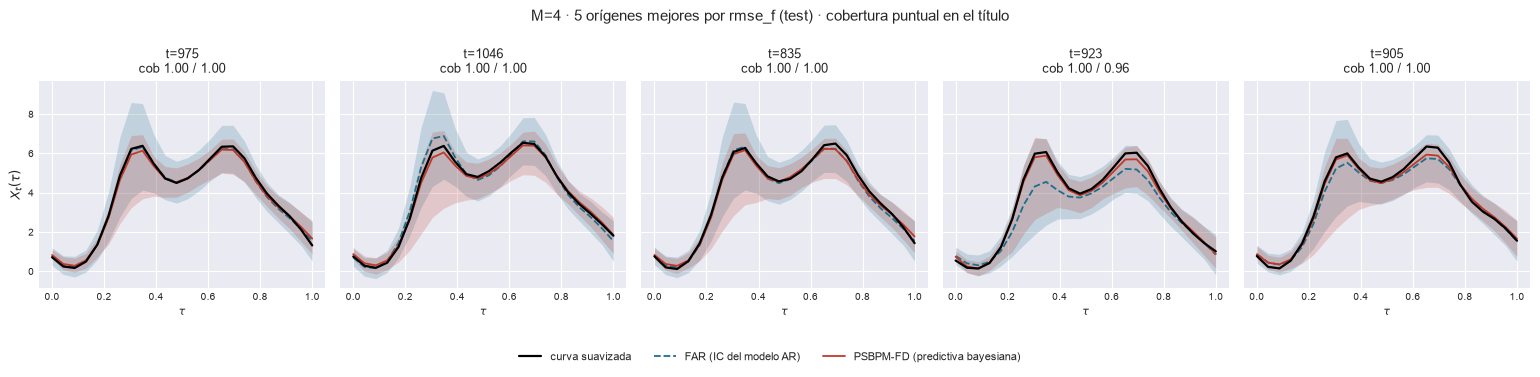

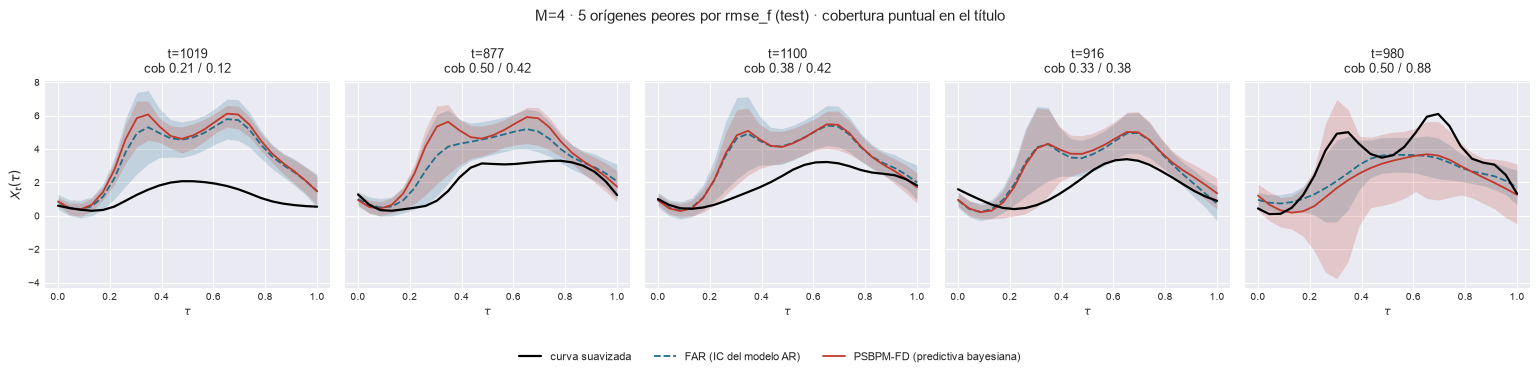

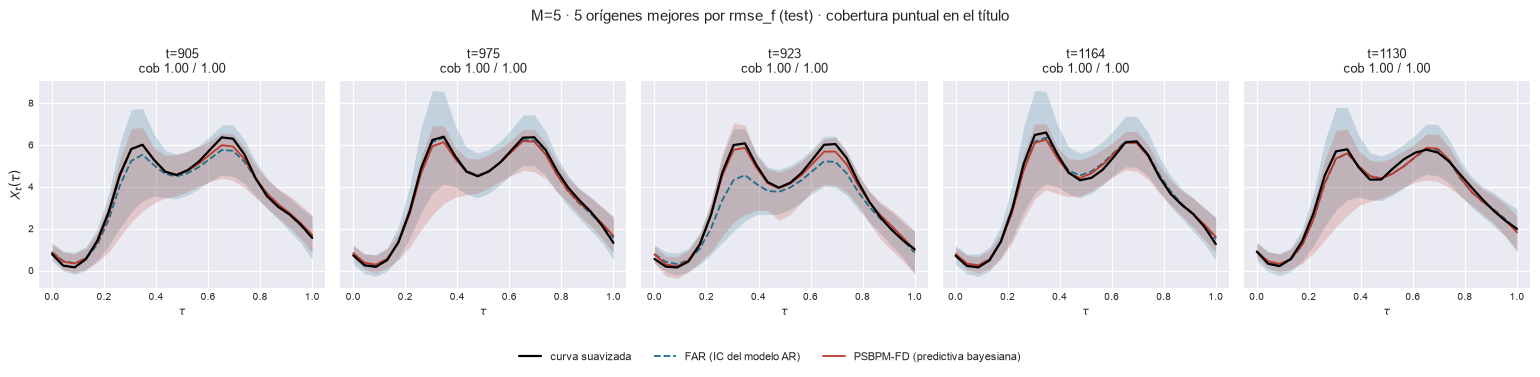

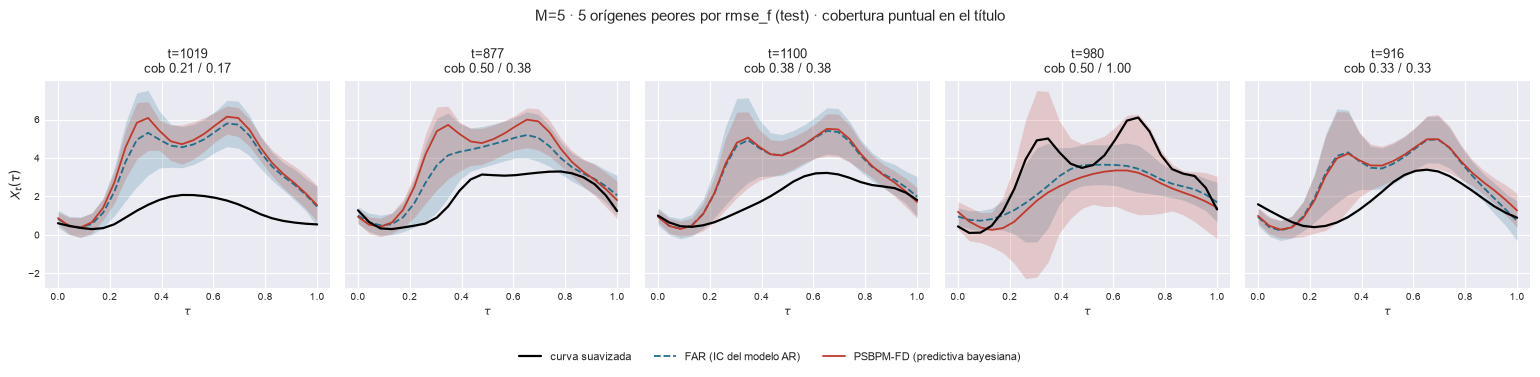

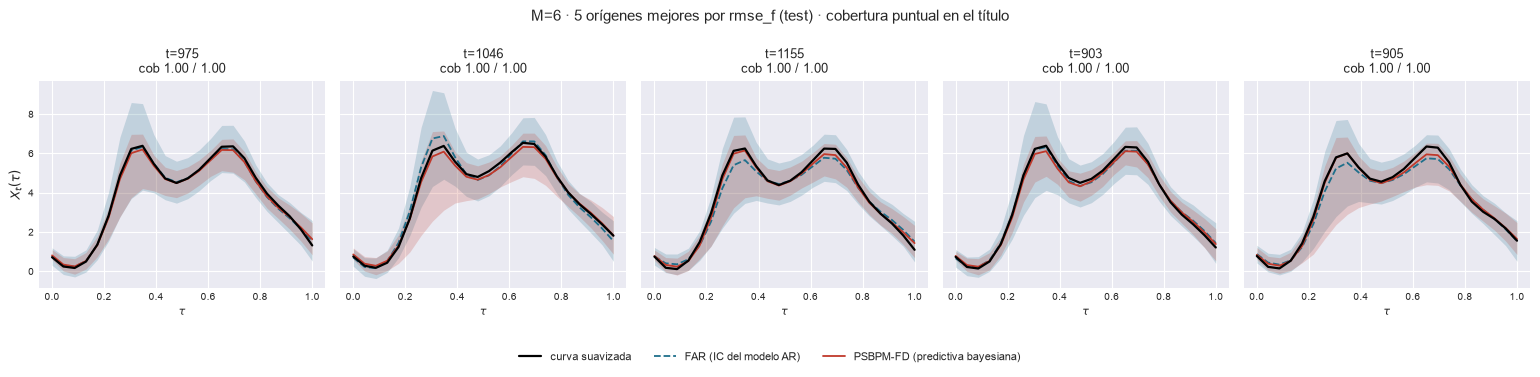

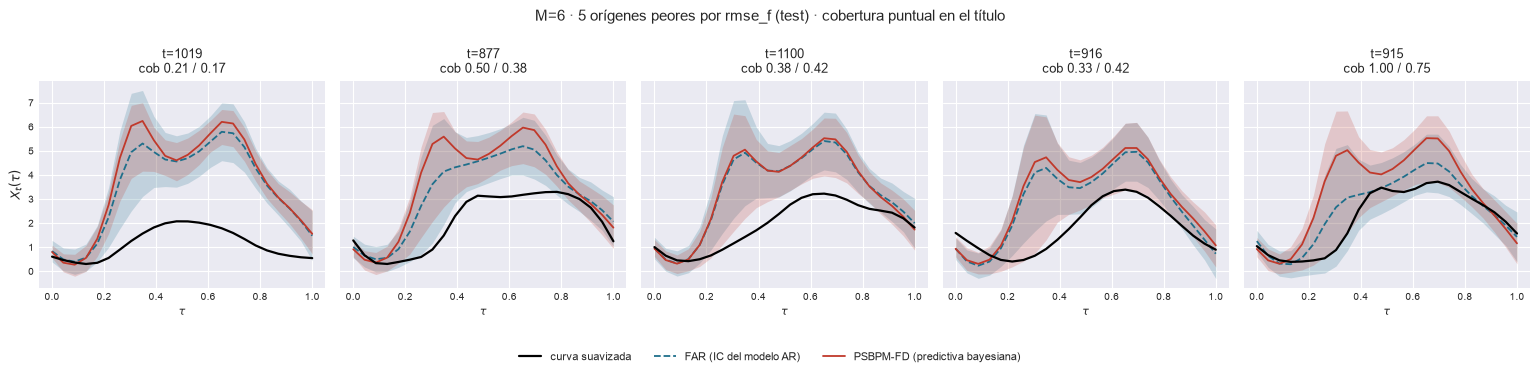

In [15]:
M_9 = M_OK if M_DETALLE is None else tuple(m for m in M_DETALLE if m in M_OK)
EXTREMOS = {M: origenes_extremos(EST[M], DIS, ORIG, METRICA_SEL_IC, N_EXTREMOS, PESOS_TAU) for M in M_9}

# Las dos bandas superpuestas sobre la misma curva.
for M in M_9:
    for grupo in ("mejores", "peores"):
        plot_bandas_contraste(
            EST[M]["BANDAS"], EXTREMOS[M], X_obj_ev, grilla, t_orig, M, METRICA_SEL_IC,
            BANDA_A_CONTRASTAR, grupo,
            EST[M]["paths"]["out_report"] / f"{PREFIJO + 9}_ic_contraste_{grupo}.png")
        plt.show()

In [16]:
# Ancho y cobertura por origen, de cada banda, en los mismos 2N orígenes.
ic_df = contraste_origenes(EST, EXTREMOS, DIS, ORIG, METRICA_SEL_IC, PREFIJO)
for M in M_9:
    display(ic_df[ic_df.M == M].drop(columns="M").set_index(["grupo", "t", "banda"]).style
            .format({f"{METRICA_SEL_IC}_PSBPM": "{:.4f}", "mpiw": "{:.4f}",
                     "picp_puntual": "{:.3f}", "I_t_simultaneo": "{:.0f}"})
            .set_caption(f"M={M} · ancho y cobertura por origen · I_t_simultaneo = 1 si la banda contiene la curva ENTERA"))
print("Lectura: si el MPIW del FAR es prácticamente el mismo en los orígenes mejores y en los peores,")
print("es porque su ancho NO depende del origen (su Sigma_eps es la misma para todo t); que el del")
print("PSBPM-FD sí cambie entre grupos es la flexibilidad de una predictiva que depende del estado.")

Lectura: si el MPIW del FAR es prácticamente el mismo en los orígenes mejores y en los peores,
es porque su ancho NO depende del origen (su Sigma_eps es la misma para todo t); que el del
PSBPM-FD sí cambie entre grupos es la flexibilidad de una predictiva que depende del estado.
